In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np

# COMPARANDO CATEGORIAS

Os gráficos deste capítulo visam ajudar nossos leitores a comparar valores entre categorias. Barras, linhas e pontos permitem que os leitores façam comparações tanto dentro de grupos quanto entre eles. Em alguns casos, queremos que o leitor visualize tanto os níveis quanto as variações, ou alguma outra combinação de variáveis; em outros, queremos concentrar sua atenção em uma comparação específica.

O desafio ao comparar dados categóricos é decidir o que queremos que o gráfico transmita. Existe um argumento ou uma narrativa principal? Há algum aspecto que possa ser identificado como a comparação mais importante que se deseja que o leitor faça? Como criadores de gráficos, precisamos priorizar a função que queremos que eles desempenhem. Ao incluir todas as barras ou pontos no gráfico, podemos acabar obscurecendo a mensagem que desejamos transmitir.

Este capítulo começa com o gráfico de barras. Assim como o gráfico de linhas que dará início ao próximo capítulo, o gráfico de barras é familiar à maioria dos leitores, o que o torna uma escolha conveniente para orientá-los ao comparar categorias ou observar mudanças ao longo do tempo. Ele também ocupa o topo do diagrama de hierarquia de percepção visual. Não é obrigatório fornecer sempre os valores exatos aos leitores, mas, quando o fazemos, o gráfico de barras é uma excelente escolha.



## GRÁFICOS DE BARRAS

Em uma das formas mais familiares de visualização de dados, o comprimento ou a altura das barras retangulares — presentes tanto em gráficos de barras quanto em gráficos de colunas — representa o valor dos dados. Os retângulos podem ser dispostos ao longo do eixo vertical, de modo que as barras fiquem na horizontal (configuração frequentemente chamada de gráfico de barras), ou ao longo do eixo horizontal, ficando na vertical (configuração frequentemente chamada de gráfico de colunas). Para simplificar — e pelo fato de que, independentemente da orientação, elas continuam sendo barras —, ao longo deste livro refiro-me a ambos os tipos simplesmente como gráficos de barras.

Os gráficos de barras ocupam o topo da lista de hierarquia de percepção visual. Como os retângulos estão alinhados ao longo de um mesmo eixo reto, é fácil comparar os valores de forma rápida e precisa. Além disso, são fáceis de criar, mesmo usando apenas papel e caneta. Este gráfico mostra a população total de dez países de várias partes do mundo. É fácil identificar os países menos populosos (Itália) e os mais populosos (Brasil) do grupo, mesmo sem a indicação dos valores exatos.


       País  População (2026) Variação Anual % Pop. Global Rank Mundial
8    França          66746401         +0,14%         0,83%          23º
1    Rússia         143394458         -0,42%         1,79%           9º
5    Vietnã         102177431         +0,57%         1,28%          16º
0    Brasil         213562666         +0,35%         2,67%           7º
7   Turquia          87926082         +0,27%         1,10%          18º
2     Japão         122427731         -0,55%         1,53%          12º
9    Itália          58926166         -0,37%         0,74%          25º
4   Etiópia         138902185         +2,53%         1,74%          10º
3    México         132997658         +0,80%         1,66%          11º
6  Alemanha          83644258         -0,51%         1,04%          19º


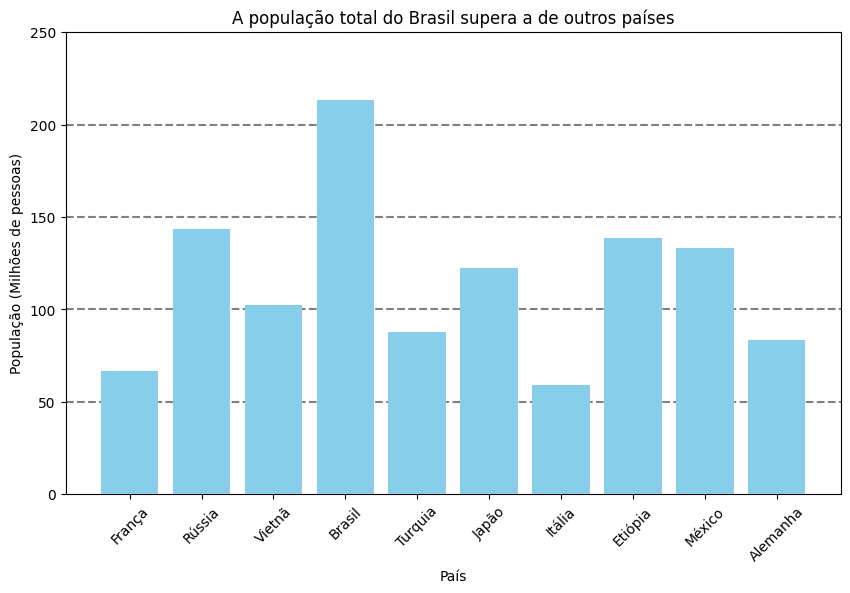

In [2]:
# Carregar os dados do arquivo CSV
data = pd.read_csv('../Data/populao-por-pas--2026.csv')

# Gerar uma ordem aleatória dos países
np.random.seed(42)  # Para reproduzibilidade
random_order = np.random.permutation(data.index)

# Selecionar os dados em ordem aleatória
data_random = data.iloc[random_order]

# Criar o gráfico de barras
plt.figure(figsize=(10, 6))
print(data_random)
plt.bar(data_random['País'], data_random['População (2026)'], color='skyblue', zorder=3)


# Adicionar títulos e rótulos dos eixos
plt.title('A população total do Brasil supera a de outros países')
plt.xlabel('País')
plt.ylabel('População (Milhões de pessoas)')

# Definir o intervalo do eixo y e os tics (incluindo o valor final de 250 milhões)
plt.ylim(0, 250000000)
plt.yticks(range(0, 250000001, 50000000))

# Adicionar linhas discontinuas horizontais em cinza nos valores dos tics, atrás das barras
plt.gca().set_axisbelow(True)  # Garantir que os eixos e as linhas sejam desenhados por traz
for i,y in enumerate(plt.yticks()[0]):
    if i > 0:  # Ignorar o primeiro valor (0) para não desenhar uma linha no eixo x
        plt.axhline(y=y, color='gray', linestyle='--', zorder=0)

# Rotacionar os rótulos dos países para melhor visualização
plt.xticks(rotation=45)

# Formatar o eixo y para mostrar em escala de 10^6 sem decimais
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{int(y / 1e6)}'))

# Mostrar o gráfico
plt.show()

É ainda mais fácil visualizar os valores mais altos e mais baixos quando os dados estão ordenados de acordo com seus respectivos valores. No entanto, essa estratégia nem sempre funciona. Se, por exemplo, eu estivesse apresentando os níveis populacionais de sessenta países, poderia ordenar os valores alfabeticamente para que os leitores encontrassem com mais facilidade a barra correspondente a um país específico. Mas, se eu estivesse argumentando sobre o nível populacional de um país ou grupo de países em particular, poderia ordenar os dados de modo que o país ou os países de interesse ficassem em uma das extremidades do gráfico. Alternativamente, eu poderia simplesmente usar uma cor diferente para destacar a barra ou as barras que desejasse diferenciar das demais.

Existem algumas estratégias para criar gráficos de barras, muitas das quais também se aplicam a outros gráficos deste capítulo.

### Comece o eixo no zero.

Iniciar o eixo de gráficos de barras no zero é uma regra prática com a qual concordam muitos especialistas e autores da área de visualização de dados. Como percebemos os valores em um gráfico de barras com base no comprimento das barras, começar o eixo em um valor diferente de zero pode superestimar a diferença entre elas e distorcer nossa percepção.

Considere o gráfico de barras da população. Como nenhum valor é inferior a cinquenta milhões, poderíamos nos sentir tentados a iniciar o eixo em cinquenta milhões. Afinal, isso destacaria a diferença entre os valores.

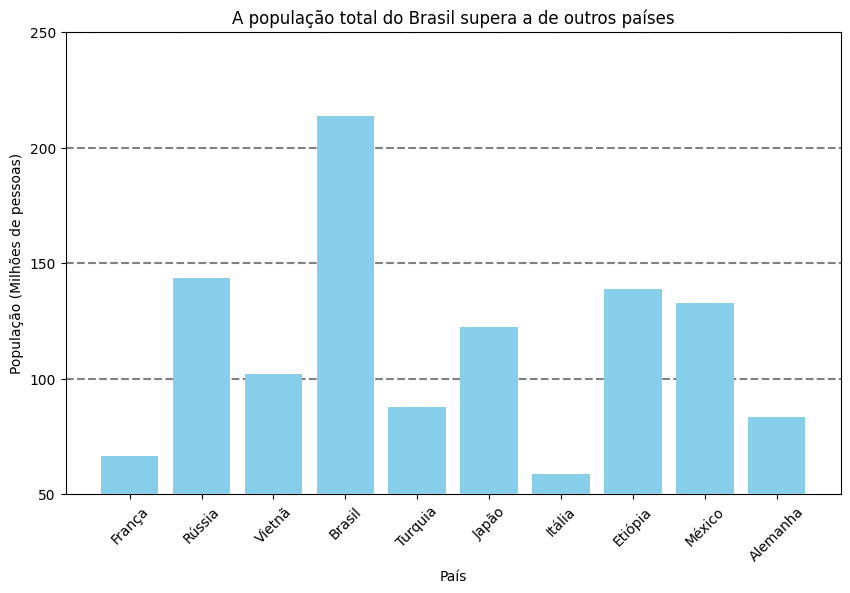

In [3]:
# Criar o gráfico de barras
plt.figure(figsize=(10, 6))
plt.bar(data_random['País'], data_random['População (2026)'], color='skyblue', zorder=3)


# Adicionar títulos e rótulos dos eixos
plt.title('A população total do Brasil supera a de outros países')
plt.xlabel('País')
plt.ylabel('População (Milhões de pessoas)')

# Definir o intervalo do eixo y e os tics (incluindo o valor final de 250 milhões)
plt.ylim(50_000_000, 250_000_000)
plt.yticks(range(50_000_000, 250_000_001, 50_000_000))

# Adicionar linhas discontinuas horizontais em cinza nos valores dos tics, atrás das barras
plt.gca().set_axisbelow(True)  # Garantir que os eixos e as linhas sejam desenhados por traz
for i, y in enumerate(plt.yticks()[0]):
    if i > 0:  # Ignorar o primeiro valor (0) para não desenhar uma linha no eixo x
        plt.axhline(y=y, color='gray', linestyle='--', zorder=0)

# Rotacionar os rótulos dos países para melhor visualização
plt.xticks(rotation=45)

# Formatar o eixo y para mostrar em escala de 10^6 sem decimais
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{int(y / 1e6)}'))

# Mostrar o gráfico
plt.show()

Mas observe o que acontece quando fazemos isso. As diferenças de valores são enfatizadas — na verdade, são superenfatizadas. Aqui, parece que o Brasil é ordens de magnitude maior do que a Itália, quando, na realidade, é apenas cerca de três vezes e meia maior. Não se trata de passar de uma percepção precisa para uma percepção geral; trata-se de passar do preciso para o impreciso.

Se você quiser levar isso a um extremo, imagine começar o gráfico em cem milhões — e por que não? Se começar em cinquenta é aceitável, então podemos escolher qualquer número arbitrário. Agora, à primeira vista, parece que ninguém vive em metade desses países!

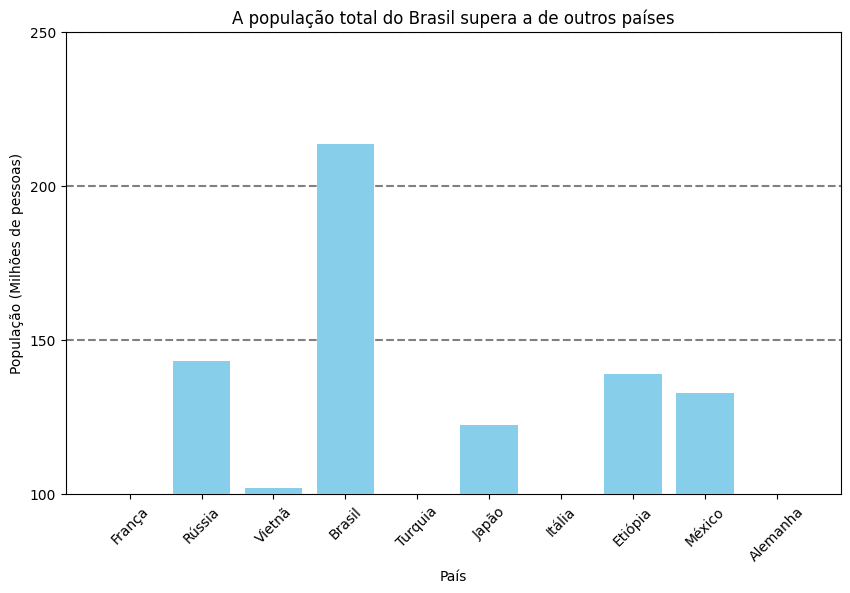

In [4]:
# Criar o gráfico de barras
plt.figure(figsize=(10, 6))
plt.bar(data_random['País'], data_random['População (2026)'], color='skyblue', zorder=3)


# Adicionar títulos e rótulos dos eixos
plt.title('A população total do Brasil supera a de outros países')
plt.xlabel('País')
plt.ylabel('População (Milhões de pessoas)')

# Definir o intervalo do eixo y e os tics (incluindo o valor final de 250 milhões)
plt.ylim(100_000_000, 250_000_000)
plt.yticks(range(100_000_000, 250_000_001, 50_000_000))

# Adicionar linhas discontinuas horizontais em cinza nos valores dos tics, atrás das barras
plt.gca().set_axisbelow(True)  # Garantir que os eixos e as linhas sejam desenhados por traz
for i, y in enumerate(plt.yticks()[0]):
    if i > 0:  # Ignorar o primeiro valor (0) para não desenhar uma linha no eixo x
        plt.axhline(y=y, color='gray', linestyle='--', zorder=0)

# Rotacionar os rótulos dos países para melhor visualização
plt.xticks(rotation=45)

# Formatar o eixo y para mostrar em escala de 10^6 sem decimais
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{int(y / 1e6)}'))

# Mostrar o gráfico
plt.show()

Há pesquisas recentes nesta área sugerindo que, talvez, iniciar gráficos de barras em um valor diferente de zero não distorça nossa percepção dos dados. Em um estudo recente, os participantes conseguiram avaliar melhor a magnitude dos resultados (por exemplo: ausência de efeito, efeito pequeno, médio ou grande) e foram mais precisos (por exemplo, quanto ao tamanho do efeito) quando o eixo vertical foi definido com uma escala mais condizente com a variação dos dados. No entanto, até que mais pesquisas sejam realizadas, prefiro iniciar o eixo dos gráficos de barras em zero para evitar qualquer confusão ou possibilidade de viés visual.

### Não quebre a barra

Outro erro grave na visualização de dados é o que se chama de "quebrar a barra" — isto é, utilizar uma linha ou forma ondulada para indicar que uma ou mais barras foram cortadas. É tentador fazer isso quando se tem um valor atípico (*outlier*), mas tal prática distorce os valores relativos entre as barras.

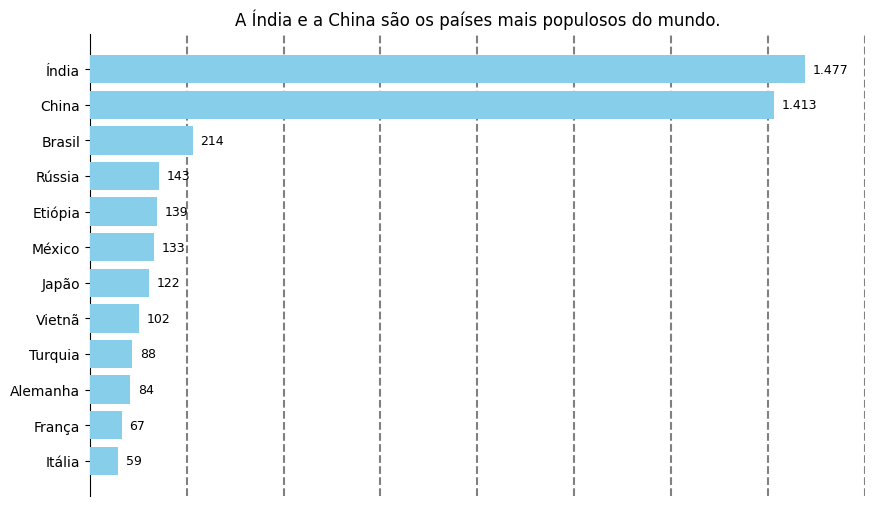

In [5]:
# Carregar os dados do arquivo CSV (números usam "." como separador de milhar)
data_completa = pd.read_csv('../Data/populao-por-pas--2026-com-china-e-ndia.csv', thousands='.')

# Criar o gráfico de barras horizontais, mantendo a ordem original do arquivo
plt.figure(figsize=(10, 6))
plt.barh(data_completa['País'], data_completa['População (2026)'], color='skyblue', zorder=3)
plt.gca().invert_yaxis()  # País mais populoso no topo

# Adicionar o valor (em milhões) ao final de cada barra
for i, valor in enumerate(data_completa['População (2026)']):
    if valor >= 1_000_000_000:
        plt.text(valor + 15_000_000, i, f'{valor / 1e9:.3f}', va='center', fontsize=9)
    else:
        plt.text(valor + 15_000_000, i, f'{valor / 1e6:.0f}', va='center', fontsize=9)

# Adicionar título
plt.title('A Índia e a China são os países mais populosos do mundo.')

# Suprimir o eixo x (marcações, rótulos e a linha do eixo)
plt.gca().xaxis.set_visible(False)
plt.gca().spines['bottom'].set_visible(False)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# Definir o limite do eixo x e adicionar linhas discontinuas verticais a cada 200 milhões
limite_x = 1_600_000_000
plt.xlim(0, limite_x)
for x in range(200_000_000, limite_x + 1, 200_000_000):
    plt.axvline(x=x, color='gray', linestyle='--', zorder=0)

# Mostrar o gráfico
plt.show()

Vamos criar um gráfico de barras da população dos países anteriores, adicionando Chin e Índia. Podemos ver como a China e a Índia são dramaticamente maiores em relação aos demais países no gráfico anterior. Se quiséssemos ampliar as diferenças entre os países menos populosos, poderíamos dividir as barras, mas isso faria com que a China e a Índia parecessem muito menos populosas do que realmente são. Cortar o comprimento das barras é completamente arbitrário — posso colocar essas linhas onduladas onde quiser para ampliar as outras diferenças. Mas isso não é ser honesto com os dados.

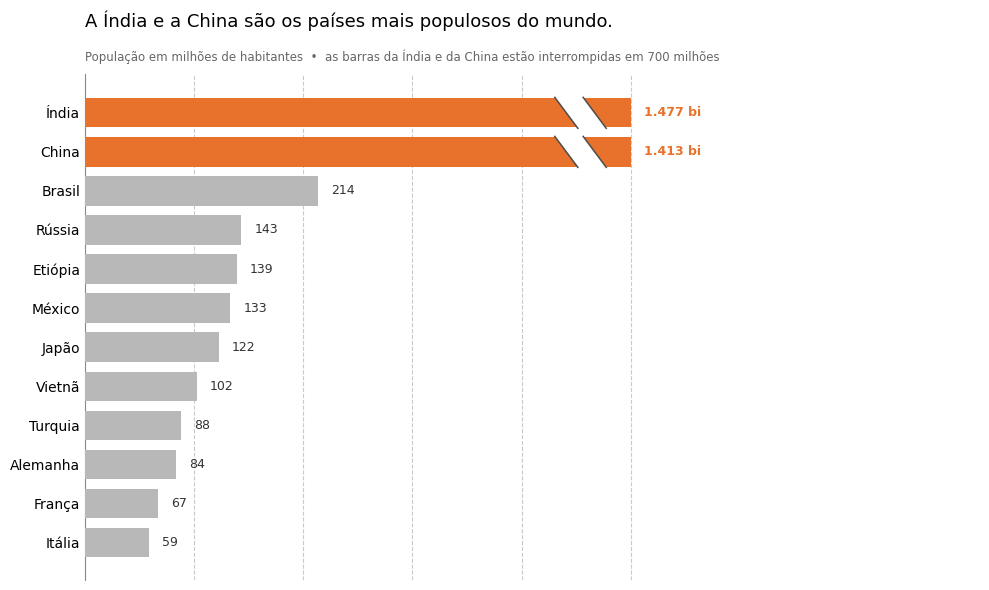

In [6]:
"""
População por país (2026) — gráfico de barras horizontais com barras cortadas.

Estratégia: as barras que ultrapassam 1 bilhão de habitantes (Índia e China) são
interrompidas em 700 milhões e recebem uma marca de corte (dupla diagonal) que
sinaliza a quebra de escala. O valor real é sempre impresso ao final da barra.
"""

import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.patches import Polygon

# --------------------------------------------------------------------------- #
# Parâmetros de escala e estilo
# --------------------------------------------------------------------------- #
LIMIAR_CORTE = 1_000_000_000     # acima disso a barra é cortada
X_CORTE      = 500_000_000       # comprimento visual das barras cortadas
LIMITE_X     = 820_000_000       # folga para os rótulos
PASSO_GRADE  = 100_000_000       # linhas de referência a cada 100 milhões

COR_BARRA    = '#b8b8b8'         # cinza: "comece com o cinza"
COR_DESTAQUE = '#E8722B'         # laranja: só as barras cortadas
COR_GRADE    = '#c9c9c9'
COR_FUNDO    = 'white'           # deve ser igual ao fundo dos eixos
ALTURA_BARRA = 0.75


def marcar_corte(ax, y, x_corte, altura=ALTURA_BARRA,
                 largura_faixa=26_000_000, inclinacao=22_000_000,
                 cor_fundo=COR_FUNDO, cor_linha='#4d4d4d'):
    """Desenha a marca de interrupção (//) sobre uma barra truncada em `x_corte`."""
    meia = altura / 2 * 1.10                 # extrapola um pouco além da barra
    x2 = x_corte - 22_000_000 - inclinacao   # borda direita da faixa branca
    x1 = x2 - largura_faixa                  # borda esquerda da faixa branca

    faixa = [(x1, y - meia), (x1 + inclinacao, y + meia),
             (x2 + inclinacao, y + meia), (x2, y - meia)]
    ax.add_patch(Polygon(faixa, closed=True, facecolor=cor_fundo,
                         edgecolor='none', zorder=4))
    for x0 in (x1, x2):
        ax.plot([x0, x0 + inclinacao], [y - meia, y + meia],
                color=cor_linha, lw=1.1, zorder=5, solid_capstyle='butt')


# --------------------------------------------------------------------------- #
# Dados
# --------------------------------------------------------------------------- #
data_completa = pd.read_csv(
    '../Data/populao-por-pas--2026-com-china-e-ndia.csv', thousands='.')

populacao = data_completa['População (2026)']
cortada = populacao >= LIMIAR_CORTE                      # máscara das barras cortadas
comprimento = populacao.where(~cortada, X_CORTE)         # comprimento desenhado
cores = [COR_DESTAQUE if c else COR_BARRA for c in cortada]

# --------------------------------------------------------------------------- #
# Gráfico
# --------------------------------------------------------------------------- #
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(data_completa['País'], comprimento, height=ALTURA_BARRA,
        color=cores, zorder=3)
ax.invert_yaxis()                                        # mais populoso no topo

# Rótulos: valor real, sempre — inclusive nas barras cortadas
for i, (valor, desenhado, e_cortada) in enumerate(zip(populacao, comprimento, cortada)):
    if e_cortada:
        texto, peso, cor = f'{valor / 1e9:.3f} bi', 'bold', COR_DESTAQUE
    else:
        texto, peso, cor = f'{valor / 1e6:.0f}', 'normal', '#333333'
    ax.text(desenhado + 12_000_000, i, texto, va='center',
            fontsize=9, fontweight=peso, color=cor)

# Título em estilo manchete + nota metodológica
ax.set_title('A Índia e a China são os países mais populosos do mundo.',
             loc='left', fontsize=13, pad=34)
ax.text(0, 1.02,
        'População em milhões de habitantes  •  as barras da Índia e da China '
        'estão interrompidas em 700 milhões',
        transform=ax.transAxes, fontsize=8.5, color='#666666', va='bottom')

# Eixo x suprimido e molduras removidas
ax.xaxis.set_visible(False)
for lado in ('top', 'right', 'bottom'):
    ax.spines[lado].set_visible(False)
ax.spines['left'].set_color('#888888')
ax.tick_params(axis='y', length=0)

# Linhas de referência a cada 100 milhões
ax.set_xlim(0, LIMITE_X)
for x in range(PASSO_GRADE, X_CORTE + 1, PASSO_GRADE):
    ax.axvline(x=x, color=COR_GRADE, linestyle='--', lw=0.8, zorder=0)

# Marca de corte nas barras truncadas
for i, e_cortada in enumerate(cortada):
    if e_cortada:
        marcar_corte(ax, i, X_CORTE)

fig.tight_layout()
plt.savefig('populacao_barras_cortadas.png', dpi=200, bbox_inches='tight')
plt.show()

Se você se deparar com uma situação em que existem valores atípicos (*outliers*), mas deseja exibir as diferenças detalhadas entre os valores menores, experimente utilizar mais gráficos. Você pode encarar isso como uma abordagem de "aproximação" (*zoom in*) e "afastamento" (*zoom out*): apresente todos os dados para que o leitor perceba a magnitude dos valores mais elevados e, em seguida, faça uma aproximação para uma visualização detalhada que exclua os valores atípicos. Na página seguinte, destaquei os países menos populosos para evidenciar as diferenças entre eles — algo que não conseguimos visualizar claramente no gráfico principal. Incluir rótulos e um título que transmita uma mensagem clara é outra excelente maneira de comunicar ao leitor as diferenças entre os valores menores.

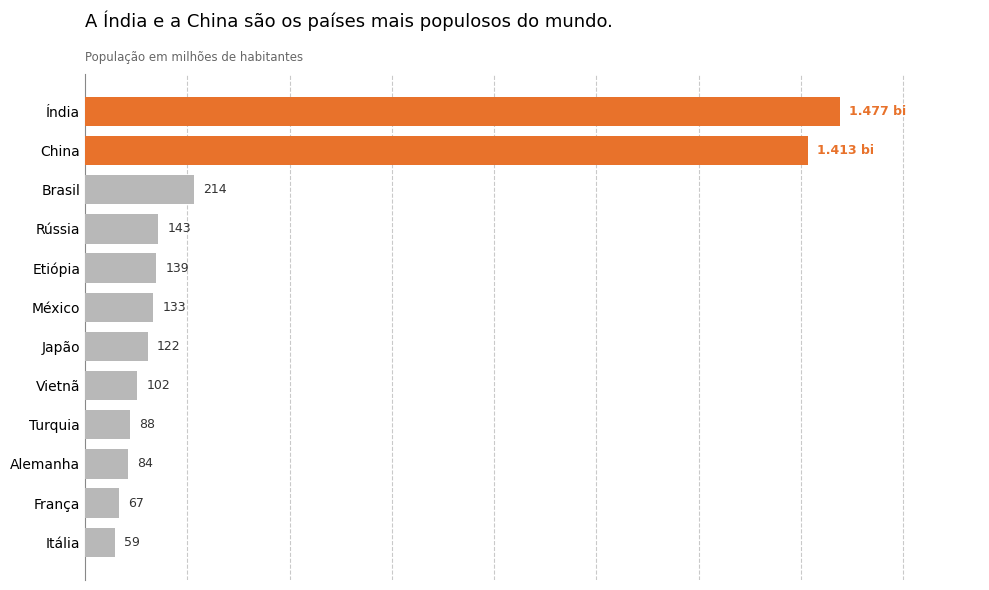

In [7]:
"""
População por país (2026) — barras horizontais em escala contínua (sem corte).

Todas as barras estão na mesma escala, do zero até o valor real. Índia e China
ficam em destaque (laranja) e os demais países em cinza.
"""

import matplotlib.pyplot as plt
import pandas as pd

# --------------------------------------------------------------------------- #
# Parâmetros de escala e estilo
# --------------------------------------------------------------------------- #
LIMIAR_DESTAQUE = 1_000_000_000    # países acima de 1 bilhão ganham destaque
LIMITE_X        = 1_750_000_000    # folga à direita para os rótulos
PASSO_GRADE     = 200_000_000      # linhas de referência a cada 200 milhões

COR_BARRA    = '#b8b8b8'           # cinza: "comece com o cinza"
COR_DESTAQUE = '#E8722B'           # laranja: apenas Índia e China
COR_GRADE    = '#c9c9c9'
ALTURA_BARRA = 0.75

# --------------------------------------------------------------------------- #
# Dados
# --------------------------------------------------------------------------- #
data_completa = pd.read_csv(
    '../Data/populao-por-pas--2026-com-china-e-ndia.csv', thousands='.')

populacao = data_completa['População (2026)']
destaque = populacao >= LIMIAR_DESTAQUE
cores = [COR_DESTAQUE if d else COR_BARRA for d in destaque]

# --------------------------------------------------------------------------- #
# Gráfico
# --------------------------------------------------------------------------- #
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(data_completa['País'], populacao, height=ALTURA_BARRA,
        color=cores, zorder=3)
ax.invert_yaxis()                                     # mais populoso no topo

# Rótulo ao final de cada barra
for i, (valor, em_destaque) in enumerate(zip(populacao, destaque)):
    if em_destaque:
        texto, peso, cor = f'{valor / 1e9:.3f} bi', 'bold', COR_DESTAQUE
    else:
        texto, peso, cor = f'{valor / 1e6:.0f}', 'normal', '#333333'
    ax.text(valor + 18_000_000, i, texto, va='center',
            fontsize=9, fontweight=peso, color=cor)

# Título em estilo manchete + nota de unidade
ax.set_title('A Índia e a China são os países mais populosos do mundo.',
             loc='left', fontsize=13, pad=34)
ax.text(0, 1.02, 'População em milhões de habitantes',
        transform=ax.transAxes, fontsize=8.5, color='#666666', va='bottom')

# Eixo x suprimido e molduras removidas
ax.xaxis.set_visible(False)
for lado in ('top', 'right', 'bottom'):
    ax.spines[lado].set_visible(False)
ax.spines['left'].set_color('#888888')
ax.tick_params(axis='y', length=0)

# Linhas de referência a cada 200 milhões, em toda a extensão da escala
ax.set_xlim(0, LIMITE_X)
for x in range(PASSO_GRADE, LIMITE_X + 1, PASSO_GRADE):
    ax.axvline(x=x, color=COR_GRADE, linestyle='--', lw=0.8, zorder=0)

fig.tight_layout()
plt.savefig('populacao_escala_completa.png', dpi=200, bbox_inches='tight')
plt.show()

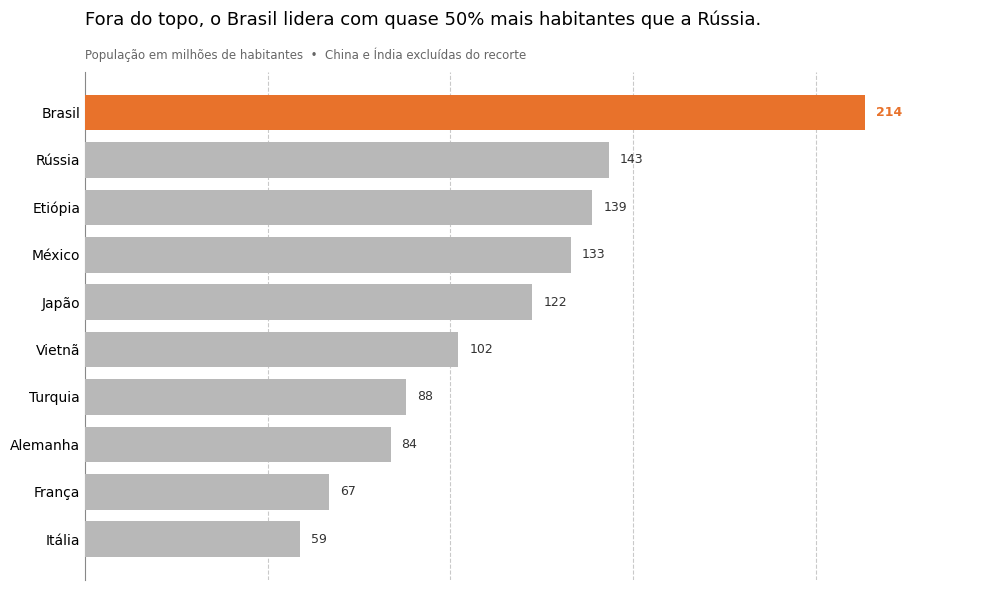

In [8]:
"""
População por país (2026) — zoom nos demais países, excluindo China e Índia.

Sem os dois casos extremos, a escala pode ir do zero ao maior valor restante
(Brasil) e as diferenças entre os países médios voltam a ser legíveis.
"""

import matplotlib.pyplot as plt
import pandas as pd

# --------------------------------------------------------------------------- #
# Parâmetros de escala e estilo
# --------------------------------------------------------------------------- #
EXCLUIDOS   = ['China', 'Índia']   # países fora deste recorte
DESTAQUE    = 'Brasil'             # país em evidência (None desliga o destaque)
LIMITE_X    = 245_000_000          # folga à direita para os rótulos
PASSO_GRADE = 50_000_000           # linhas de referência a cada 50 milhões

COR_BARRA    = '#b8b8b8'           # cinza: "comece com o cinza"
COR_DESTAQUE = '#E8722B'           # laranja: um único acento
COR_GRADE    = '#c9c9c9'
ALTURA_BARRA = 0.75

# --------------------------------------------------------------------------- #
# Dados
# --------------------------------------------------------------------------- #
data_completa = pd.read_csv(
    '../Data/populao-por-pas--2026-com-china-e-ndia.csv', thousands='.')

# Recorte: remove os extremos, preservando a ordem original do arquivo
dados = data_completa[~data_completa['País'].isin(EXCLUIDOS)].reset_index(drop=True)

populacao = dados['População (2026)']
destaque = dados['País'] == DESTAQUE
cores = [COR_DESTAQUE if d else COR_BARRA for d in destaque]

# --------------------------------------------------------------------------- #
# Gráfico
# --------------------------------------------------------------------------- #
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(dados['País'], populacao, height=ALTURA_BARRA, color=cores, zorder=3)
ax.invert_yaxis()                                     # mais populoso no topo

# Rótulo ao final de cada barra
for i, (valor, em_destaque) in enumerate(zip(populacao, destaque)):
    ax.text(valor + 3_000_000, i, f'{valor / 1e6:.0f}', va='center', fontsize=9,
            fontweight='bold' if em_destaque else 'normal',
            color=COR_DESTAQUE if em_destaque else '#333333')

# Título em estilo manchete + nota de recorte
ax.set_title('Fora do topo, o Brasil lidera com quase 50% mais habitantes que a Rússia.',
             loc='left', fontsize=13, pad=34)
ax.text(0, 1.02,
        'População em milhões de habitantes  •  China e Índia excluídas do recorte',
        transform=ax.transAxes, fontsize=8.5, color='#666666', va='bottom')

# Eixo x suprimido e molduras removidas
ax.xaxis.set_visible(False)
for lado in ('top', 'right', 'bottom'):
    ax.spines[lado].set_visible(False)
ax.spines['left'].set_color('#888888')
ax.tick_params(axis='y', length=0)

# Linhas de referência a cada 50 milhões
ax.set_xlim(0, LIMITE_X)
for x in range(PASSO_GRADE, LIMITE_X + 1, PASSO_GRADE):
    ax.axvline(x=x, color=COR_GRADE, linestyle='--', lw=0.8, zorder=0)

fig.tight_layout()
plt.savefig('populacao_zoom_sem_extremos.png', dpi=200, bbox_inches='tight')
plt.show()

### Valores extremos ou *outliers*

Um *outlier* (valor atípico) é um ponto de dados que está muito distante das outras observações do seu conjunto de dados. Ele pode resultar de variabilidade aleatória nos dados, de erro de medição ou de uma anomalia real. Os *outliers* representam tanto uma oportunidade quanto um alerta: podem indicar algo muito interessante para se analisar ou sinalizar que há algum problema nos dados.

Em 2014, o BuzzFeed fez uma parceria com o site Pornhub para analisar o consumo de pornografia por estado. Utilizando dados de geolocalização de pessoas que acessavam o site, o Pornhub calculou o número de visualizações de página por pessoa em cada estado. Constatou-se que os habitantes do Kansas assistiam a muito mais pornografia do que os de qualquer outro estado do país: 194 visualizações de página por pessoa. O Nevada ficou em segundo lugar, com 166 visualizações.

Os dados foram utilizados no gráfico de dispersão abaixo, que compara o consumo de pornografia em estados de maioria democrata ("estados azuis") e republicana ("estados vermelhos"). É possível identificar claramente o Kansas como um ponto fora da curva em termos de visualizações de página. Será que as pessoas no Kansas realmente consomem tanta pornografia a mais?

Acontece que a resposta é não. Ao que parece, a metodologia do Pornhub atribuía dados de geolocalização ausentes ao centro geográfico dos Estados Unidos — que, como se vê, é o Kansas.

No entanto, nem todos os valores atípicos são erros. Como apenas um exemplo, podemos observar a taxa de violência física envolvendo armas de fogo em países desenvolvidos. Em 2017, mais de 8 em cada 100.000 pessoas foram vítimas de violência por arma de fogo nos Estados Unidos, em comparação com 0,90 por 100.000 no Canadá e 0,49 por 100.000 na Bélgica. Em alguns casos, valores atípicos são, de fato, atípicos.

Existem muitas maneiras de identificar *outliers* (valores atípicos) em seus dados, algumas mais complexas do que outras. Uma delas é simplesmente observar os dados. A exploração dos dados não precisa começar com matemática e estatística complexas; você deve sempre inspecionar visualmente os seus dados.

No entanto, essa abordagem dificilmente pode ser considerada matemática. Um método padrão consiste em comparar os valores dos dados com 1,5 vez a amplitude interquartil (IQR). A IQR é um resumo simples dos seus dados e corresponde à diferença entre o terceiro e o primeiro quartis (veja o quadro sobre percentis mais adiante).

### Use marcas de escala e linhas de grade com critério.

Gráficos de barras não precisam de marcas de escala entre as barras. O espaço em branco é um separador eficaz, e remover as marcas de escala reduz a poluição visual.

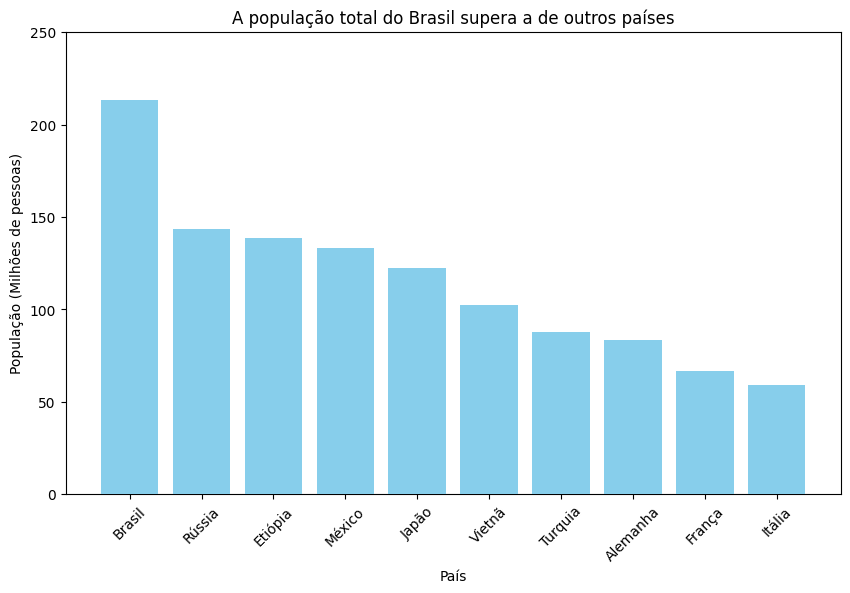

In [9]:
# Carregar os dados do arquivo CSV
data = pd.read_csv('../Data/populao-por-pas--2026.csv')
# Ordenar os dados em ordem decrwcente de população
data = data.sort_values(by='População (2026)', ascending=False)

# Criar o gráfico de barras
plt.figure(figsize=(10, 6))
plt.bar(data['País'], data['População (2026)'], color='skyblue', zorder=3)


# Adicionar títulos e rótulos dos eixos
plt.title('A população total do Brasil supera a de outros países')
plt.xlabel('País')
plt.ylabel('População (Milhões de pessoas)')

# Definir o intervalo do eixo y e os tics (incluindo o valor final de 250 milhões)
plt.ylim(0, 250000000)
plt.yticks(range(0, 250000001, 50000000))


# Rotacionar os rótulos dos países para melhor visualização
plt.xticks(rotation=45)

# Formatar o eixo y para mostrar em escala de 10^6 sem decimais
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{int(y / 1e6)}'))

# Mostrar o gráfico
plt.show()

Uma exceção ocorre se você tiver um rótulo de categoria "principal" que abrange várias barras. Nesses casos, marcas de escala maiores podem ajudar a agrupar os rótulos.

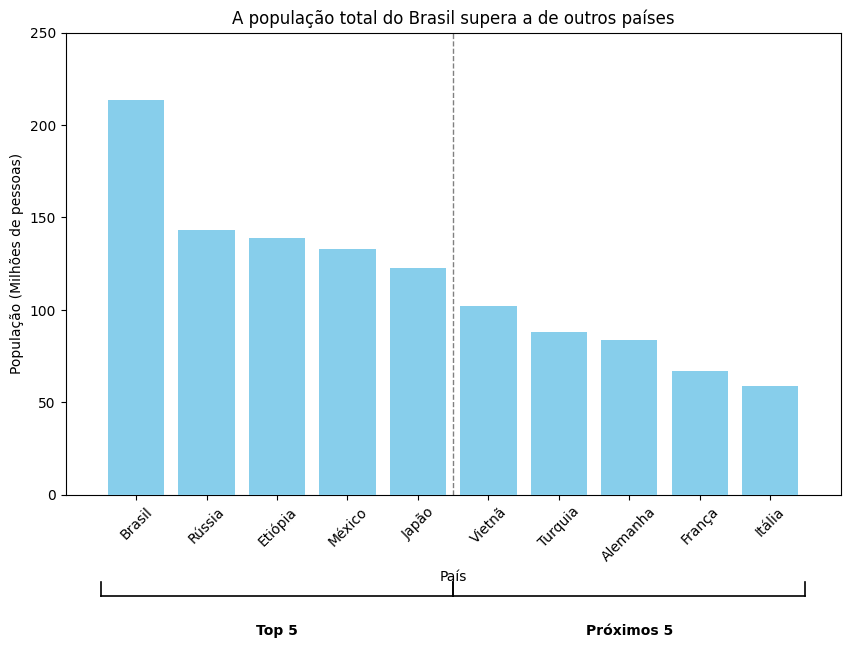

In [10]:
# Separar, no gráfico o grupo do Top 5 (o grupo de 5 países com mais população do conjunto
# de dados) do restante dos países que será agrupada como Próximos 5 (o grupo de 5 países 
# com menos população do conjunto de dados)
# Criar o gráfico de barras
plt.figure(figsize=(10, 6))
plt.bar(data['País'], data['População (2026)'], color='skyblue', zorder=3)


# Adicionar títulos e rótulos dos eixos
plt.title('A população total do Brasil supera a de outros países')
plt.xlabel('País')
plt.ylabel('População (Milhões de pessoas)')

# Definir o intervalo do eixo y e os tics (incluindo o valor final de 250 milhões)
plt.ylim(0, 250000000)
plt.yticks(range(0, 250000001, 50000000))


# Rotacionar os rótulos dos países para melhor visualização
plt.xticks(rotation=45)

# Formatar o eixo y para mostrar em escala de 10^6 sem decimais
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{int(y / 1e6)}'))

# Separar visualmente o Top 5 dos Próximos 5 com uma linha e marcas de escala maiores
ax = plt.gca()
trans = ax.get_xaxis_transform()  # x em dados, y em fração dos eixos
ax.axvline(x=4.5, color='gray', linestyle='--', linewidth=1, zorder=0)
for inicio, fim, rotulo in [(-0.5, 4.5, 'Top 5'), (4.5, 9.5, 'Próximos 5')]:
    ax.plot([inicio, fim], [-0.22, -0.22], color='black', linewidth=1.2,
            transform=trans, clip_on=False)
    for x in (inicio, fim):
        ax.plot([x, x], [-0.22, -0.19], color='black', linewidth=1.2,
                transform=trans, clip_on=False)
    ax.text((inicio + fim) / 2, -0.28, rotulo, transform=trans,
            ha='center', va='top', fontsize=10, fontweight='bold')

# Mostrar o gráfico
plt.show()

As linhas de grade ajudam o leitor a visualizar os valores específicos de cada barra e são especialmente úteis para as barras mais distantes do rótulo do eixo. Por servirem como guia visual, podem ser exibidas em uma cor mais clara, permitindo que o olhar do leitor permaneça focado nos dados.

Quando é importante que o leitor saiba os valores exatos, você pode adicionar rótulos de dados ao gráfico. Nesses casos, prefiro dispensar totalmente as linhas de grade e as linhas dos eixos.

Observe a Itália nos dois gráficos a seguir (destacada em azul). Sem os rótulos, a linha de grade nos ajuda a perceber que há mais de cinquenta milhões de pessoas vivendo no país; com o rótulo, fica claro que são cinquenta e oito milhões de pessoas e, portanto, as linhas de grade provavelmente não são necessárias.

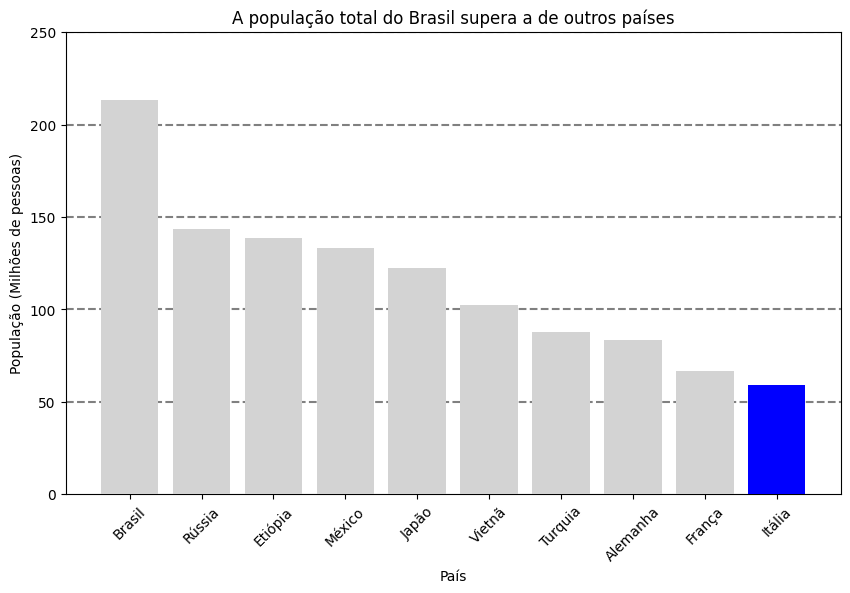

In [11]:
# Carregar os dados do arquivo CSV
data = pd.read_csv('../Data/populao-por-pas--2026.csv')
# Ordenar os dados em ordem decrwcente de população
data = data.sort_values(by='População (2026)', ascending=False)

# Criar o gráfico de barras
# Separar "Italia em azul dos outros países em cinza"
plt.figure(figsize=(10, 6))
plt.bar(data['País'], data['População (2026)'], color='lightgray', zorder=3)
plt.bar(data[data['País'] == 'Itália']['País'], data[data['País'] == 'Itália']['População (2026)'], color='blue', zorder=4)


# Adicionar títulos e rótulos dos eixos
plt.title('A população total do Brasil supera a de outros países')
plt.xlabel('País')
plt.ylabel('População (Milhões de pessoas)')

# Definir o intervalo do eixo y e os tics (incluindo o valor final de 250 milhões)
plt.ylim(0, 250000000)
plt.yticks(range(0, 250000001, 50000000))

# Adicionar linhas discontinuas horizontais em cinza nos valores dos tics, atrás das barras
plt.gca().set_axisbelow(True)  # Garantir que os eixos e as linhas sejam desenhados por traz
for i,y in enumerate(plt.yticks()[0]):
    if i > 0:  # Ignorar o primeiro valor (0) para não desenhar uma linha no eixo x
        plt.axhline(y=y, color='gray', linestyle='--', zorder=0)

# Rotacionar os rótulos dos países para melhor visualização
plt.xticks(rotation=45)

# Formatar o eixo y para mostrar em escala de 10^6 sem decimais
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{int(y / 1e6)}'))

# Mostrar o gráfico
plt.show()

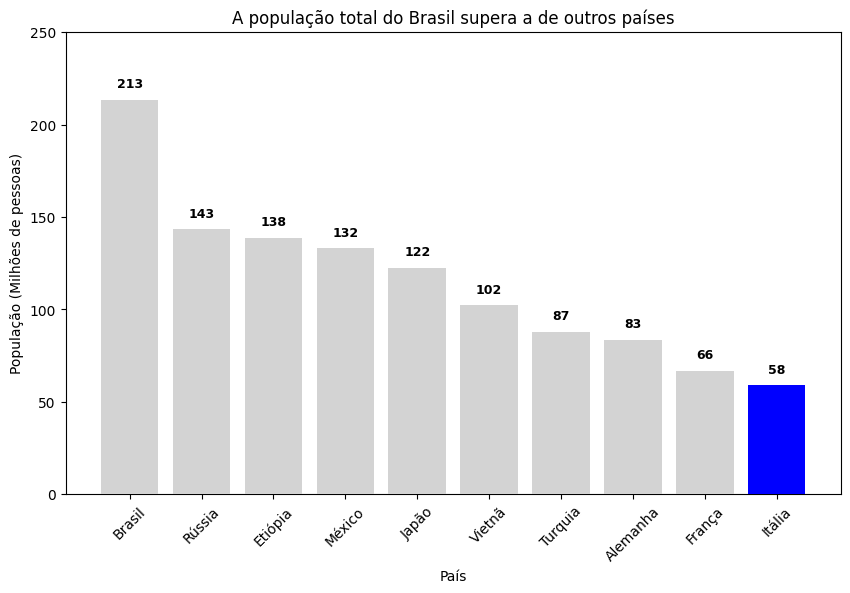

In [12]:
# Carregar os dados do arquivo CSV
data = pd.read_csv('../Data/populao-por-pas--2026.csv')
# Ordenar os dados em ordem decrwcente de população
data = data.sort_values(by='População (2026)', ascending=False)

# Criar o gráfico de barras
# Separar "Italia em azul dos outros países em cinza"
plt.figure(figsize=(10, 6))
plt.bar(data['País'], data['População (2026)'], color='lightgray', zorder=3)
plt.bar(data[data['País'] == 'Itália']['País'], data[data['País'] == 'Itália']['População (2026)'], color='blue', zorder=4)


# Adicionar títulos e rótulos dos eixos
plt.title('A população total do Brasil supera a de outros países')
plt.xlabel('País')
plt.ylabel('População (Milhões de pessoas)')

# Definir o intervalo do eixo y e os tics (incluindo o valor final de 250 milhões)
plt.ylim(0, 250000000)
plt.yticks(range(0, 250000001, 50000000))

# Adicionar, no topo da coluna, o valor do da coluna em milhões, sem decimais, e em negrito
for i, (pais, populacao) in enumerate(zip(data['País'], data['População (2026)'])):
    plt.text(i, populacao + 5_000_000, f'{int(populacao / 1e6)}', ha='center', va='bottom', fontweight='bold', fontsize=9)
    

# Rotacionar os rótulos dos países para melhor visualização
plt.xticks(rotation=45)

# Formatar o eixo y para mostrar em escala de 10^6 sem decimais
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{int(y / 1e6)}'))

# Mostrar o gráfico
plt.show()

O gráfico poderia ficar visualmente sobrecarregado de rótulos se eu incluísse cinquenta ou talvez até vinte países; por isso, eu poderia optar por incluir uma tabela separada ou um apêndice. Remover as linhas de grade ao utilizar rótulos de dados é, sobretudo, uma escolha estética; à medida que você continuar trabalhando com dados e criando seus próprios gráficos, desenvolverá seu próprio estilo para esses elementos gráficos.

### Girar rótulos do eixo longo

A solução padrão para rótulos longos no eixo horizontal é dispor o texto na vertical, como na lombada de um livro. No entanto, essa abordagem obriga o leitor a virar a cabeça para o lado. Uma solução é rotacioná-los em 45 graus, mas o leitor ainda precisa virar a cabeça. Outra alternativa é reduzir o tamanho da fonte para que fiquem alinhados horizontalmente — embora isso geralmente os torne pequenos demais.

A solução mais elegante é simplesmente rotacionar o gráfico inteiro. Isso ainda utiliza o mesmo atributo pré-atentivo — o comprimento das barras —, mas os rótulos dos eixos passam a ficar alinhados horizontalmente; eles são fáceis de ler, sem comprometer a compreensão dos dados.

### Variações do gráfico de barras

Existem inúmeras maneiras de modificar o gráfico de barras padrão. Uma variação simples é utilizar outras formas em vez de barras. O gráfico de pirulito (*lollipop chart*), por exemplo, substitui a barra por uma linha com um ponto na extremidade. Essa versão fica um pouco abaixo do gráfico de barras em nossa hierarquia de percepção visual, pois não é exatamente claro qual parte do círculo representa o valor. Por outro lado, ela reduz significativamente a quantidade de tinta na página, proporcionando mais espaço em branco para a inclusão de rótulos ou outras anotações.

Este é apenas um exemplo de formato alternativo. Triângulos, quadrados e setas são outras opções, assim como imagens em forma de barra que reforçam os dados apresentados. Um gráfico que mostre dados sobre crescimento urbano pode utilizar barras em formato de edifícios, enquanto um gráfico sobre mudanças climáticas pode empregar árvores como barras. No entanto, é preciso ter cautela com essa abordagem, pois os leitores podem interpretar a área total dos ícones como um indicador de valor, em vez de considerar apenas a altura.

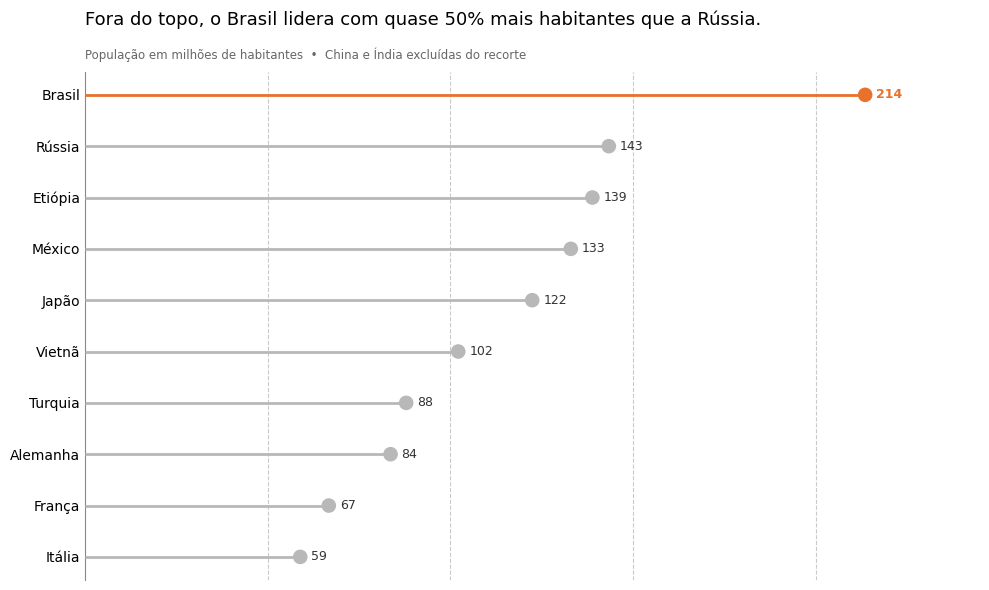

In [13]:
"""
População por país (2026) — versão em Lollipop Chart do gráfico da célula 8.

Mesmo recorte (sem China e Índia) e mesmo destaque (Brasil), mas substituindo
as barras por uma haste (plt.hlines) terminada em um marcador (plt.scatter).
"""

import matplotlib.pyplot as plt
import pandas as pd

# --------------------------------------------------------------------------- #
# Parâmetros de escala e estilo
# --------------------------------------------------------------------------- #
EXCLUIDOS   = ['China', 'Índia']   # países fora deste recorte
DESTAQUE    = 'Brasil'             # país em evidência (None desliga o destaque)
LIMITE_X    = 245_000_000          # folga à direita para os rótulos
PASSO_GRADE = 50_000_000           # linhas de referência a cada 50 milhões

COR_BARRA    = '#b8b8b8'           # cinza: "comece com o cinza"
COR_DESTAQUE = '#E8722B'           # laranja: um único acento
COR_GRADE    = '#c9c9c9'
TAMANHO_CABECA = 90                # tamanho do marcador da "cabeça" do pirulito

# --------------------------------------------------------------------------- #
# Dados
# --------------------------------------------------------------------------- #
data_completa = pd.read_csv(
    '../Data/populao-por-pas--2026-com-china-e-ndia.csv', thousands='.')

# Recorte: remove os extremos, preservando a ordem original do arquivo
dados = data_completa[~data_completa['País'].isin(EXCLUIDOS)].reset_index(drop=True)

populacao = dados['População (2026)']
destaque = dados['País'] == DESTAQUE
cores = [COR_DESTAQUE if d else COR_BARRA for d in destaque]
posicoes = range(len(dados))

# --------------------------------------------------------------------------- #
# Gráfico
# --------------------------------------------------------------------------- #
fig, ax = plt.subplots(figsize=(10, 6))

# Haste do pirulito
ax.hlines(y=posicoes, xmin=0, xmax=populacao, color=cores, linewidth=2, zorder=3)
# Cabeça do pirulito
ax.scatter(populacao, posicoes, s=TAMANHO_CABECA, color=cores, zorder=4)

ax.set_yticks(list(posicoes))
ax.set_yticklabels(dados['País'])
ax.invert_yaxis()                                     # mais populoso no topo

# Rótulo ao final de cada pirulito
for i, (valor, em_destaque) in enumerate(zip(populacao, destaque)):
    ax.text(valor + 3_000_000, i, f'{valor / 1e6:.0f}', va='center', fontsize=9,
            fontweight='bold' if em_destaque else 'normal',
            color=COR_DESTAQUE if em_destaque else '#333333')

# Título em estilo manchete + nota de recorte
ax.set_title('Fora do topo, o Brasil lidera com quase 50% mais habitantes que a Rússia.',
             loc='left', fontsize=13, pad=34)
ax.text(0, 1.02,
        'População em milhões de habitantes  •  China e Índia excluídas do recorte',
        transform=ax.transAxes, fontsize=8.5, color='#666666', va='bottom')

# Eixo x suprimido e molduras removidas
ax.xaxis.set_visible(False)
for lado in ('top', 'right', 'bottom'):
    ax.spines[lado].set_visible(False)
ax.spines['left'].set_color('#888888')
ax.tick_params(axis='y', length=0)

# Linhas de referência a cada 50 milhões
ax.set_xlim(0, LIMITE_X)
for x in range(PASSO_GRADE, LIMITE_X + 1, PASSO_GRADE):
    ax.axvline(x=x, color=COR_GRADE, linestyle='--', lw=0.8, zorder=0)

fig.tight_layout()
plt.show()

Outra abordagem em relação ao gráfico de barras básico é abandonar a grade habitual e, em vez disso, dispor as barras em um círculo, o que é chamado de layout radial. Existem duas formas comuns de fazer isso: o gráfico de barras radial e o gráfico de barras circular.

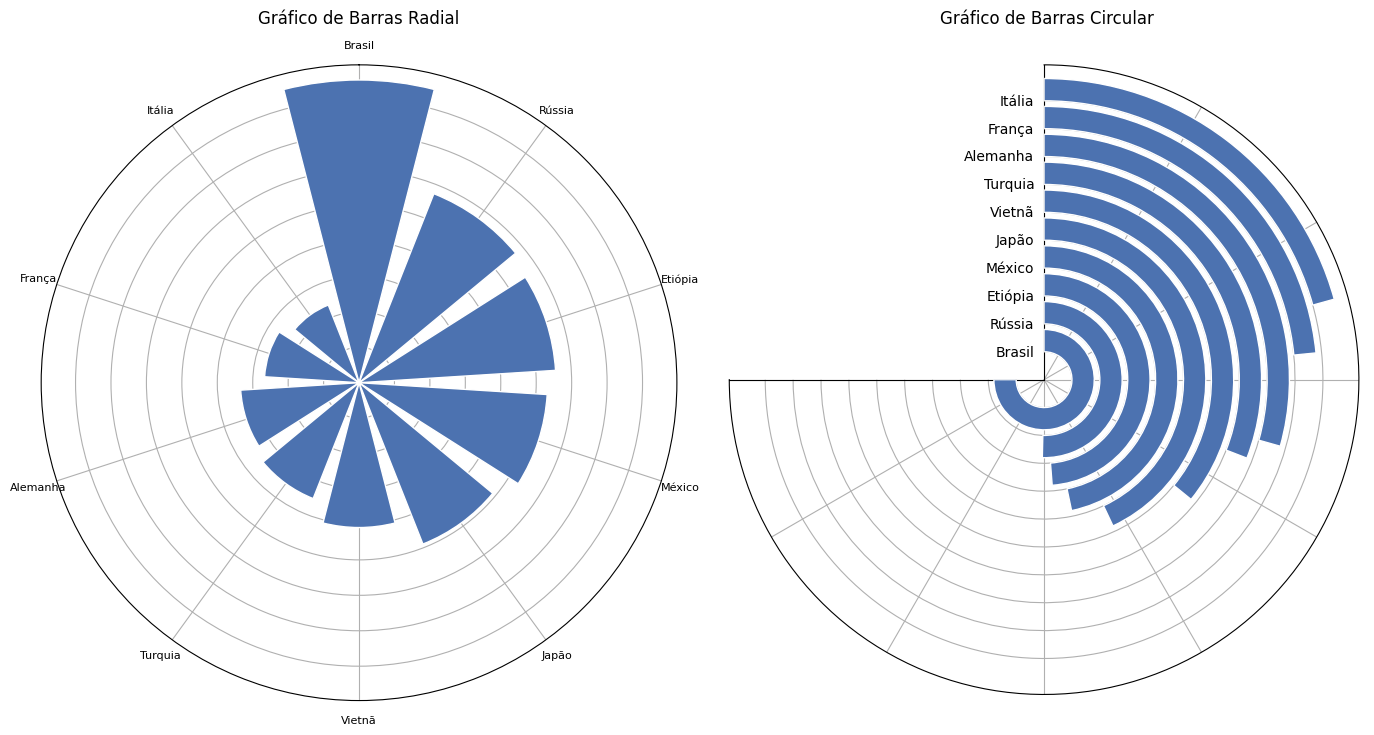

In [14]:
"""
População por país (2026) — layout radial em dois subplots com projeção polar.

Esquerda:  Circular Bar Chart — cada país ocupa um ângulo (fatia) e o
           comprimento radial representa o valor (barras "enroladas" em círculo).
Direita:   Radial Bar Chart — cada país ocupa um anel concêntrico de raio fixo,
           e o arco (ângulo) representa o valor, como um velocímetro.
"""

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# --------------------------------------------------------------------------- #
# Dados
# --------------------------------------------------------------------------- #
EXCLUIDOS = ['China', 'Índia']   # países fora deste recorte

data_completa = pd.read_csv(
    '../Data/populao-por-pas--2026-com-china-e-ndia.csv', thousands='.')
data_completa = data_completa[~data_completa['País'].isin(EXCLUIDOS)]
data_completa = data_completa.sort_values(
    by='População (2026)', ascending=False).reset_index(drop=True)

paises = data_completa['País']
populacao = data_completa['População (2026)']
n = len(data_completa)

COR_BARRA = '#4C72B0'

fig = plt.figure(figsize=(14, 7))

# --------------------------------------------------------------------------- #
# Esquerda: Gráfico de Barras Circular — ângulo = categoria, raio = valor
# --------------------------------------------------------------------------- #
ax1 = fig.add_subplot(1, 2, 1, projection='polar')

theta = np.linspace(0, 2 * np.pi, n, endpoint=False)
largura_angular = (2 * np.pi / n) * 0.8

ax1.bar(theta, populacao, width=largura_angular, color=COR_BARRA,
        edgecolor='white', zorder=3)
ax1.set_theta_zero_location('N')
ax1.set_theta_direction(-1)
ax1.set_xticks(theta)
ax1.set_xticklabels(paises, fontsize=8)
ax1.set_yticklabels([])  # os valores radiais não são o foco, apenas o comprimento
ax1.set_title('Gráfico de Barras Radial', pad=30)

# --------------------------------------------------------------------------- #
# Direita: Gráfico de Barras Radial — anel = categoria, arco = valor
# --------------------------------------------------------------------------- #
ax2 = fig.add_subplot(1, 2, 2, projection='polar')

angulo_maximo = 1.5 * np.pi                        # 270°, como um velocímetro
largura_angular_valor = (populacao / populacao.max()) * angulo_maximo
raio_anel = np.arange(1, n + 1)                    # cada país em um anel próprio
espessura_anel = 0.8

ax2.bar(x=largura_angular_valor / 2, height=espessura_anel,
        width=largura_angular_valor, bottom=raio_anel,
        color=COR_BARRA, edgecolor='white', zorder=3)
ax2.set_theta_zero_location('N')
ax2.set_theta_direction(-1)
ax2.set_thetamin(0)
ax2.set_thetamax(np.degrees(angulo_maximo))
ax2.set_xticklabels([])  # aqui o ângulo representa o valor, não uma categoria
ax2.set_yticks(raio_anel)
ax2.set_yticklabels(paises, fontsize=8)
ax2.set_title('Gráfico de Barras Circular', pad=30)

fig.tight_layout()
plt.show()

O gráfico de barras radial, também chamado de gráfico de barras polar, dispõe as barras de modo que irradiem para fora a partir do centro de um círculo. Esse tipo de gráfico ocupa uma posição inferior na hierarquia de percepção visual, pois é mais difícil comparar as alturas de barras dispostas em torno de um círculo do que quando estão alinhadas ao longo de um eixo plano único. No entanto, esse layout permite acomodar mais valores em um espaço compacto, tornando o gráfico de barras radial ideal para exibir um volume maior de dados, variações frequentes (como mudanças mensais ou diárias) ou alterações ao longo de um longo período.

Do ponto de vista da percepção, o gráfico de barras circular é problemático porque distorce a nossa percepção dos dados — neste caso, os comprimentos das barras não correspondem aos seus valores reais. Considere a situação em que os valores de duas barras são iguais: as extremidades das barras ficarão alinhadas na mesma posição, mas os comprimentos das barras não são, de fato, iguais, pois elas se estendem ao longo da circunferência de dois círculos distintos. O autor e especialista em visualização de dados Andy Kirk utiliza uma corrida olímpica como metáfora. Os corredores largam de posições escalonadas na pista, mas todos acabam percorrendo a mesma distância, uma vez que o corredor na raia externa tem um percurso maior a cumprir do que o corredor na raia interna. Nesse caso, a visualização não apenas cai na hierarquia de eficácia perceptiva, mas sai dela completamente por distorcer os dados; por isso, recomendo evitar totalmente esse tipo de gráfico.

## BARRAS PAREADAS

Um gráfico de barras simples é ideal para fazer comparações entre categorias, como comparar populações de diferentes países. Se eu quiser mostrar comparações não apenas entre países, mas também dentro deles, o gráfico de barras pareadas é uma boa opção. Esse tipo de gráfico é familiar para a maioria dos leitores e fácil de ler; além disso, a linha de base compartilhada facilita a realização de comparações.

Digamos que queiramos mostrar o número de homens e mulheres em cada país da nossa amostra. Um gráfico de barras pareadas nos permite fazer isso.

Observe que o gráfico de barras pareadas direciona a atenção do leitor não apenas para os níveis, mas também para a diferença. Se for importante que os leitores vejam ambos, esta é uma boa opção.

Mas, se o nosso objetivo é fazer com que o leitor foque apenas na diferença entre os dois valores dentro de cada categoria, essa não é a maneira mais direta de fazê-lo, pois estamos pedindo que ele compare a diferença de comprimentos. Em vez disso, poderíamos simplesmente mostrar a diferença entre os dois valores em uma única barra, como a que aparece abaixo.

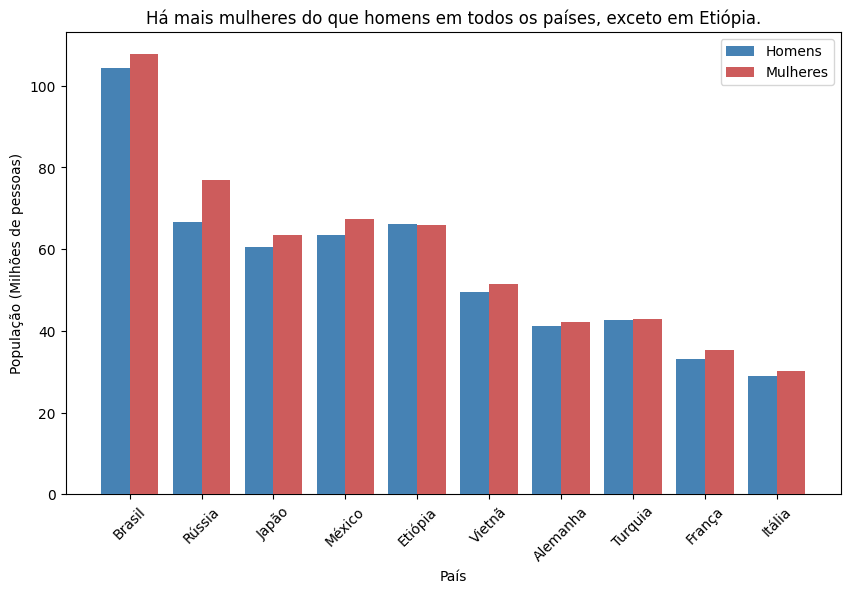

In [15]:
# Carregar os dados de população por sexo (números usam "." como separador de milhar)
data_sexo = pd.read_csv('../Data/populao-por-sexo-2024---world-bank.csv', thousands='.')

# Identificar os países em que há mais homens do que mulheres
paises_excecao = data_sexo[data_sexo['Pop. Masculina'] > data_sexo['Pop. Feminina']]['País'].tolist()

# Posições das barras pareadas: uma barra para cada sexo, lado a lado por país
posicoes = np.arange(len(data_sexo))
largura_barra = 0.4

# Criar o gráfico de barras pareadas
plt.figure(figsize=(10, 6))
plt.bar(posicoes - largura_barra / 2, data_sexo['Pop. Masculina'], width=largura_barra,
        color='steelblue', zorder=3, label='Homens')
plt.bar(posicoes + largura_barra / 2, data_sexo['Pop. Feminina'], width=largura_barra,
        color='indianred', zorder=3, label='Mulheres')

# Adicionar título e rótulos dos eixos
plt.title(f'Há mais mulheres do que homens em todos os países, exceto em {", ".join(paises_excecao)}.')
plt.xlabel('País')
plt.ylabel('População (Milhões de pessoas)')

# Posicionar os rótulos dos países no centro de cada par de barras
plt.xticks(posicoes, data_sexo['País'], rotation=45)

# Formatar o eixo y para mostrar em escala de 10^6 sem decimais
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{int(y / 1e6)}'))

plt.legend()

# Mostrar o gráfico
plt.show()

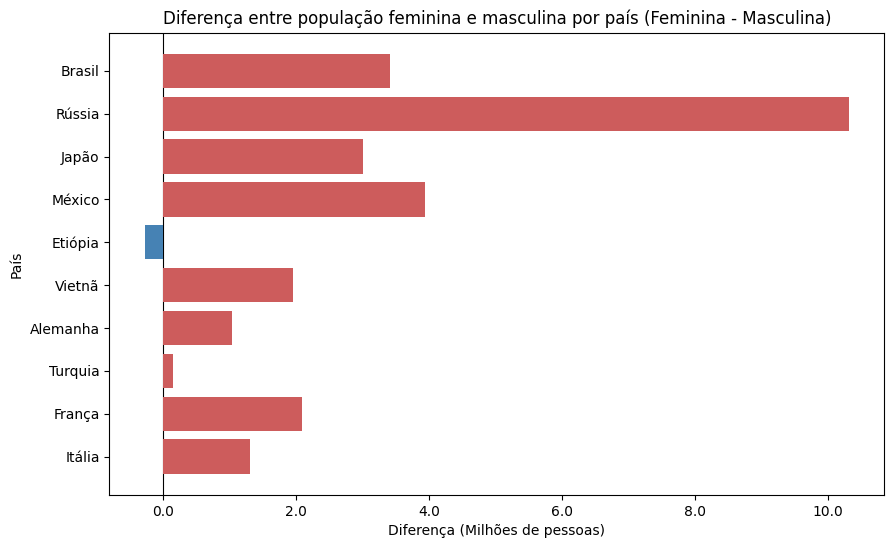

In [16]:
# Calcular a diferença entre população feminina e masculina por país
diferenca = data_sexo['Pop. Feminina'] - data_sexo['Pop. Masculina']
cores_diferenca = ['indianred' if d >= 0 else 'steelblue' for d in diferenca]

# Criar o gráfico de barras horizontais da diferença
plt.figure(figsize=(10, 6))
plt.barh(data_sexo['País'], diferenca, color=cores_diferenca, zorder=3)
plt.gca().invert_yaxis()

# Adicionar título e rótulos dos eixos
plt.title('Diferença entre população feminina e masculina por país (Feminina - Masculina)')
plt.xlabel('Diferença (Milhões de pessoas)')
plt.ylabel('País')

# Linha de referência no zero
plt.axvline(x=0, color='black', linewidth=0.8, zorder=2)

# Formatar o eixo x para mostrar em escala de 10^6 sem decimais
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x / 1e6:.1f}'))

# Mostrar o gráfico
plt.show()

Nos casos em que você deseja que o leitor visualize o nível e a diferença, pode ser necessário utilizar um tipo de gráfico totalmente diferente. Eu prefiro o gráfico de coordenadas paralelas (veja a página 263), o gráfico de inclinação (para dados que variam ao longo do tempo; veja a página 150) e o gráfico de pontos (veja a página 97). Lembre-se de perguntar a si mesmo: qual é o objetivo deste gráfico? Essa pergunta o guiará para a melhor maneira de visualizar seus dados.

Outra aplicação do gráfico de barras pareadas é mostrar mudanças ao longo do tempo. E, embora o termo "pareadas" conste no título, esses gráficos podem apresentar mais de dois valores. O gráfico abaixo, por exemplo, mostra a população de cinco de nossos países entre 2014 e 2018. Isso permite ao leitor analisar a variação populacional dentro de cada país e as diferenças entre eles.

Os padrões presentes em seus dados também podem orientar a escolha do tipo de gráfico. Se os valores apresentarem um declínio uniforme ao longo dos anos para todas as categorias, um gráfico de barras pareadas pode ser adequado. No entanto, se os valores oscilarem ao longo do tempo, um gráfico de linhas ou um gráfico de ciclos pode facilitar as comparações temporais, tanto dentro de cada grupo quanto entre eles.

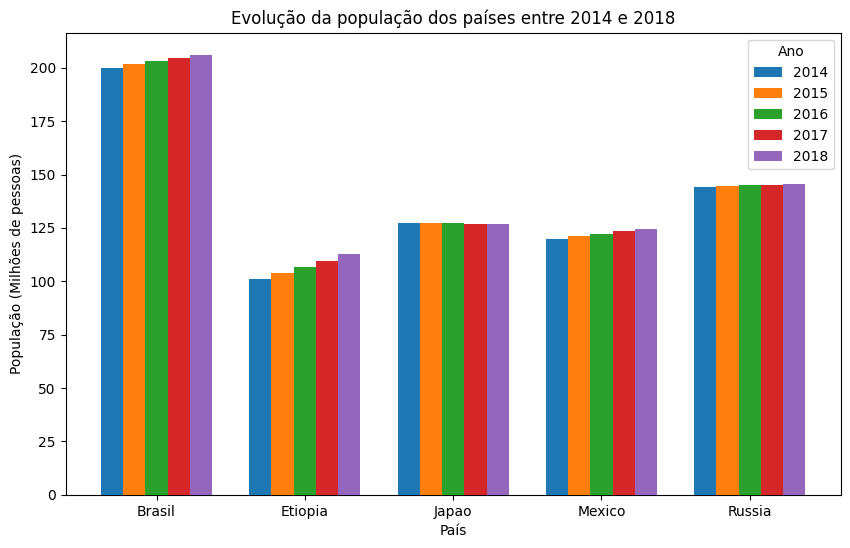

In [17]:
# Carregar os dados (arquivo em UTF-16, separado por tabulação, com uma linha de comentário)
data_evolucao = pd.read_csv('../Data/populacao_worldbank_2014_2018.csv',
                             encoding='utf-16', sep='\t', skiprows=1)

anos = ['2014', '2015', '2016', '2017', '2018']
posicoes = np.arange(len(data_evolucao))
largura_barra = 0.15

# Criar o gráfico de barras pareadas: um grupo de barras (uma por ano) por país
plt.figure(figsize=(10, 6))
for i, ano in enumerate(anos):
    deslocamento = (i - (len(anos) - 1) / 2) * largura_barra
    plt.bar(posicoes + deslocamento, data_evolucao[ano], width=largura_barra,
            zorder=3, label=ano)

# Adicionar título e rótulos dos eixos
plt.title('Evolução da população dos países entre 2014 e 2018')
plt.xlabel('País')
plt.ylabel('População (Milhões de pessoas)')

# Posicionar os rótulos dos países no centro de cada grupo de barras
plt.xticks(posicoes, data_evolucao['Pais'])

# Formatar o eixo y para mostrar em escala de 10^6 sem decimais
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{int(y / 1e6)}'))

plt.legend(title='Ano')

# Mostrar o gráfico
plt.show()

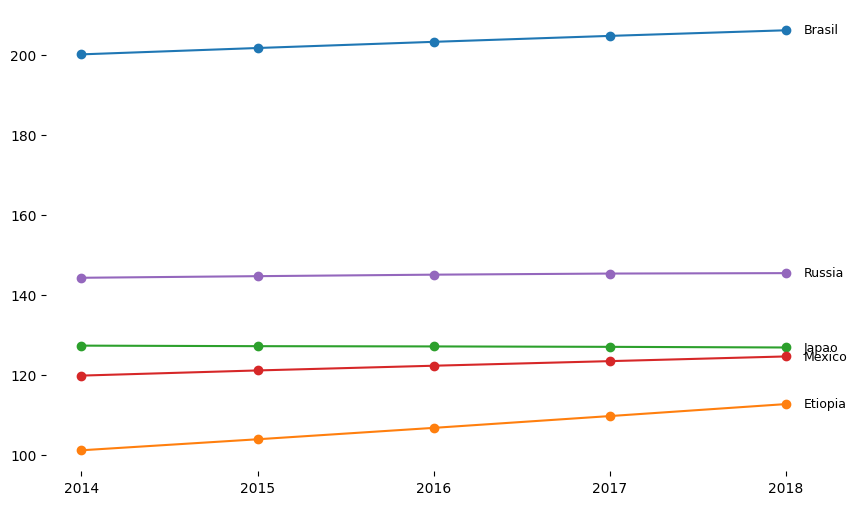

In [18]:
# Criar o gráfico de linhas: um plot (uma linha) por país
plt.figure(figsize=(10, 6))
for _, linha in data_evolucao.iterrows():
    plt.plot(anos, linha[anos], marker='o', zorder=3)
    # Anotar o nome do país ao final de cada curva, à direita
    plt.text(len(anos) - 1 + 0.1, linha[anos[-1]], linha['Pais'], va='center', fontsize=9)

# Formatar o eixo y para mostrar em escala de 10^6 sem decimais
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{int(y / 1e6)}'))

# Remover o frame externo do gráfico
for lado in ('top', 'right', 'bottom', 'left'):
    plt.gca().spines[lado].set_visible(False)

# Mostrar o gráfico
plt.show()

Há duas situações em que prefiro usar gráficos de barras em vez de gráficos de linha para mostrar mudanças ao longo do tempo. Primeiro, quando há poucos pontos de dados — por exemplo, apenas cinco anos —, a maior quantidade de tinta nas cinco barras confere ao gráfico mais peso visual. Segundo, quando trabalho com intervalos de tempo discretos (e poucas observações), como o primeiro trimestre do ano.

O excesso de elementos visuais é o principal aspecto a considerar ao avaliar se um gráfico de barras pareadas é a abordagem adequada. Com muitas barras — e, especialmente, quando há mais de duas barras por categoria —, pode ser difícil para o leitor identificar padrões e determinar se a comparação mais importante ocorre entre as diferentes categorias ou dentro delas.

Ao avaliar se um gráfico de barras pareadas está visualmente sobrecarregado, confie em seus olhos e em sua intuição. Coloque-se no lugar dos leitores: tente imaginar para onde o olhar deles se voltará ao verem o gráfico pela primeira vez. Se houver muita informação, talvez seja necessário dividir os dados, utilizar outro tipo de gráfico ou adotar uma abordagem de múltiplos pequenos gráficos (*small multiples*).

## BARRAS EMPILHADAS

Outra variação do gráfico de barras é o gráfico de barras empilhadas. Enquanto o gráfico de barras agrupadas exibe dois ou mais valores de dados para cada categoria, este gráfico subdivide os dados dentro de cada categoria. As categorias podem somar um mesmo total — digamos, 100% —, de modo que o comprimento total da barra seja igual para todos os grupos. Por outro lado, os totais podem variar entre os grupos; nesse caso, o comprimento total de cada barra também pode variar. Acima, apresentei a parcela do Produto Interno Bruto (PIB) que cada um dos dez países dedica a programas de assistência à saúde, apoio à terceira idade e outras iniciativas. O comprimento total das barras indica quanto cada país gasta nesses programas em relação ao seu PIB.

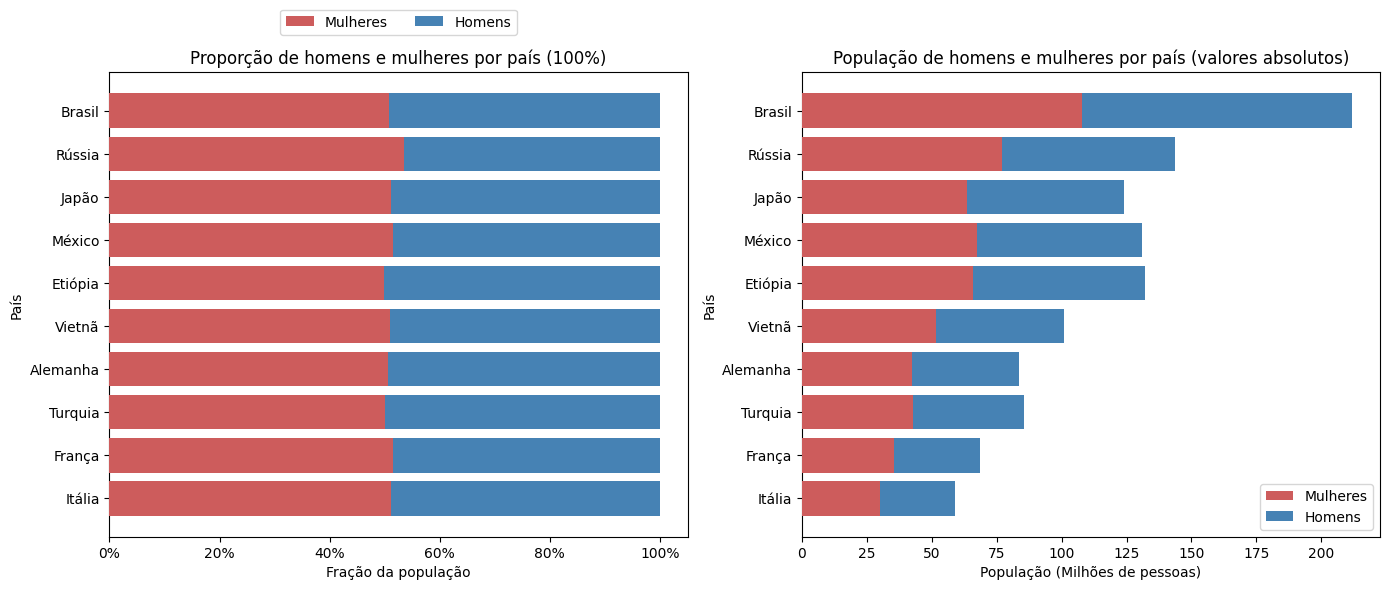

In [19]:
# Calcular as frações de homens e mulheres em relação ao total de cada país
total_populacao = data_sexo['Pop. Masculina'] + data_sexo['Pop. Feminina']
fracao_feminina = data_sexo['Pop. Feminina'] / total_populacao
fracao_masculina = data_sexo['Pop. Masculina'] / total_populacao

posicoes = np.arange(len(data_sexo))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# --------------------------------------------------------------------------- #
# Esquerda: barras empilhadas em 100% (todas as barras com o mesmo comprimento)
# --------------------------------------------------------------------------- #
ax1.barh(posicoes, fracao_feminina, color='indianred', zorder=3, label='Mulheres')
ax1.barh(posicoes, fracao_masculina, left=fracao_feminina, color='steelblue',
         zorder=3, label='Homens')
ax1.invert_yaxis()

ax1.set_title('Proporção de homens e mulheres por país (100%)')
ax1.set_ylabel('País')
ax1.set_xlabel('Fração da população')
ax1.set_yticks(posicoes)
ax1.set_yticklabels(data_sexo['País'])
ax1.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x * 100)}%'))
ax1.legend(loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=2)

# --------------------------------------------------------------------------- #
# Direita: barras empilhadas com os valores absolutos (comprimento total varia)
# --------------------------------------------------------------------------- #
ax2.barh(posicoes, data_sexo['Pop. Feminina'], color='indianred', zorder=3, label='Mulheres')
ax2.barh(posicoes, data_sexo['Pop. Masculina'], left=data_sexo['Pop. Feminina'],
         color='steelblue', zorder=3, label='Homens')
ax2.invert_yaxis()

ax2.set_title('População de homens e mulheres por país (valores absolutos)')
ax2.set_ylabel('País')
ax2.set_xlabel('População (Milhões de pessoas)')
ax2.set_yticks(posicoes)
ax2.set_yticklabels(data_sexo['País'])
ax2.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x / 1e6)}'))
ax2.legend()

fig.tight_layout()
plt.show()

Assim como os gráficos de barras que analisamos até agora, o gráfico de barras empilhadas é familiar, fácil de ler e fácil de criar. O maior desafio, no entanto, é que pode ser difícil comparar os diferentes valores dos segmentos dentro do gráfico. No exemplo acima, é fácil comparar os valores entre os países para a categoria "Saúde", pois os segmentos das barras compartilham a mesma linha de base vertical. Mas isso é mais difícil de fazer com as outras duas séries, pois elas não compartilham uma linha de base. Qual país gasta mais com programas para a terceira idade: Itália ou Grécia? Percebe-se rapidamente que a Itália gasta mais com programas de saúde do que a Grécia, porque esses segmentos estão alinhados à esquerda no eixo vertical, mas é muito mais difícil determinar isso em relação aos segmentos das outras categorias.

Uma maneira de lidar com a linha de base variável é desmembrar o gráfico, de modo que cada série fique em sua própria linha de base vertical. Trata-se de um gráfico de múltiplos pequenos (*small multiples*), dispostos lado a lado. Agora fica mais fácil perceber que a Grécia gasta mais com programas voltados para a terceira idade do que a Itália. A contrapartida é que se torna mais difícil (ou até impossível) visualizar os valores totais. No entanto, isso também pode ser contornado: é possível desmembrar o gráfico de barras empilhadas e adicionar um segmento final que represente o valor total (isso não chega a ser um problema quando a soma de todas as séries resulta em 100%, pois todos os segmentos somados terão o mesmo comprimento).

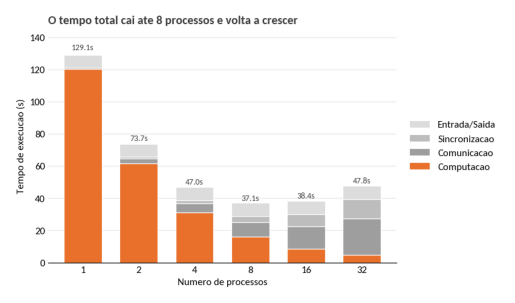

In [23]:
# Carregar a figura fig1_empilhado_totais_variáveis.png que está na sub pasta figures e mostrar com o imshow do matplotlib.pyplot
# Tirar os eixos e mostrar a figura com o plt.show()

img = mpimg.imread('figures/fig1_empilhado_totais_variaveis.png')
plt.imshow(img)
plt.axis('off')
plt.show()

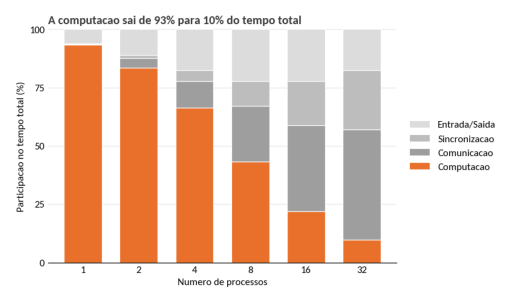

In [24]:
img = mpimg.imread('figures/fig2_empilhado_100_por_cento.png')
plt.imshow(img)
plt.axis('off')
plt.show()

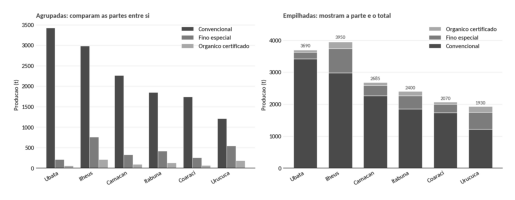

In [25]:
img = mpimg.imread('figures/fig3_agrupadas_vs_empilhadas.png')
plt.imshow(img)
plt.axis('off')
plt.show()

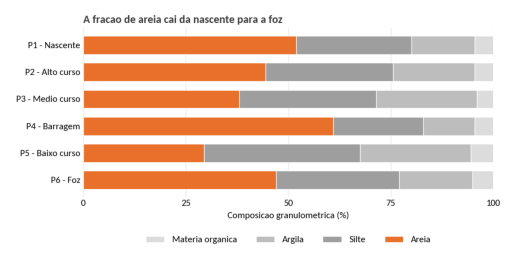

In [26]:
img = mpimg.imread('figures/fig4_empilhado_horizontal_100.png')
plt.imshow(img)
plt.axis('off')
plt.show()

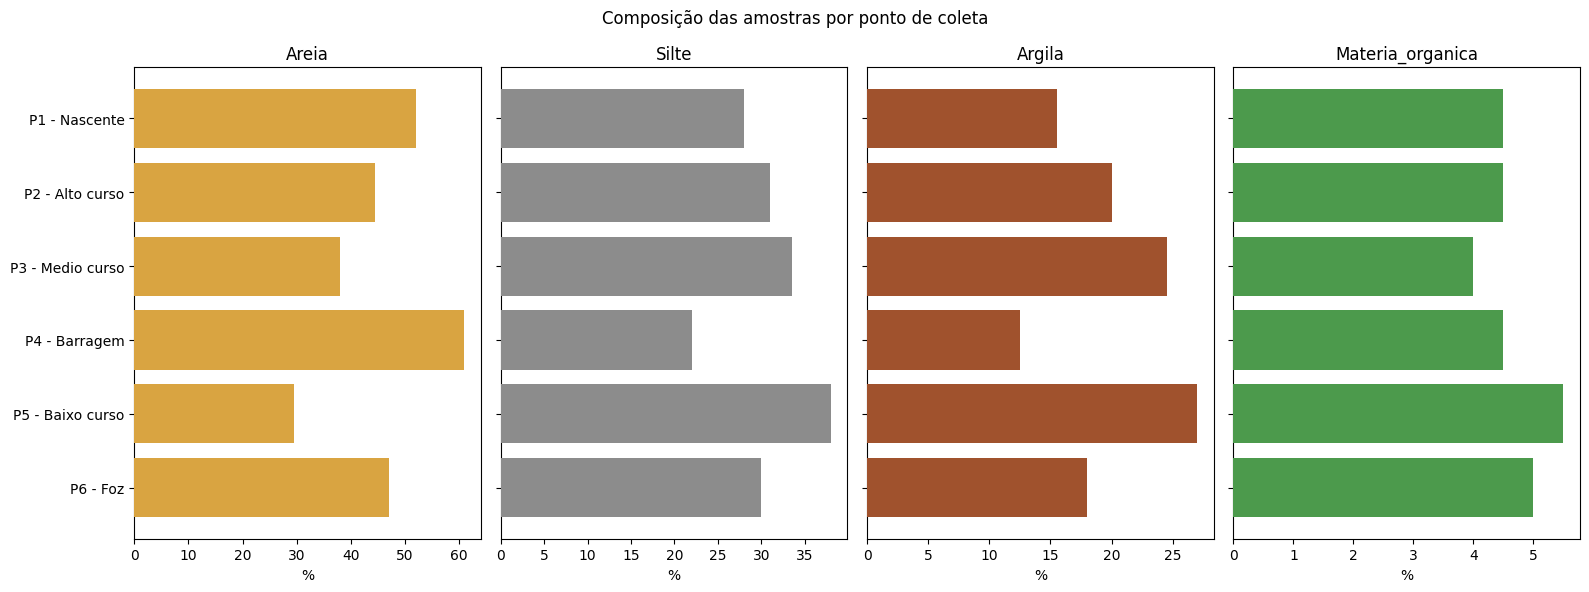

In [28]:
# Carregar os dados de composição das amostras por ponto de coleta
composicao = pd.read_csv('../Data/composicao_amostras.csv')

componentes = ['Areia', 'Silte', 'Argila', 'Materia_organica']
cores = ['#d9a441', '#8c8c8c', '#a0522d', '#4c9a4c']
posicoes = np.arange(len(composicao))

# Criar os múltiplos pequenos: um gráfico de barras (horizontais) por componente, lado a lado
fig, eixos = plt.subplots(1, len(componentes), figsize=(16, 6), sharey=True)

for ax, componente, cor in zip(eixos, componentes, cores):
    ax.barh(posicoes, composicao[componente], color=cor, zorder=3)
    ax.set_title(componente)
    ax.set_xlabel('%')

eixos[0].set_yticks(posicoes)
eixos[0].set_yticklabels(composicao['ponto_coleta'])
eixos[0].invert_yaxis()

fig.suptitle('Composição das amostras por ponto de coleta')
fig.tight_layout()
plt.show()

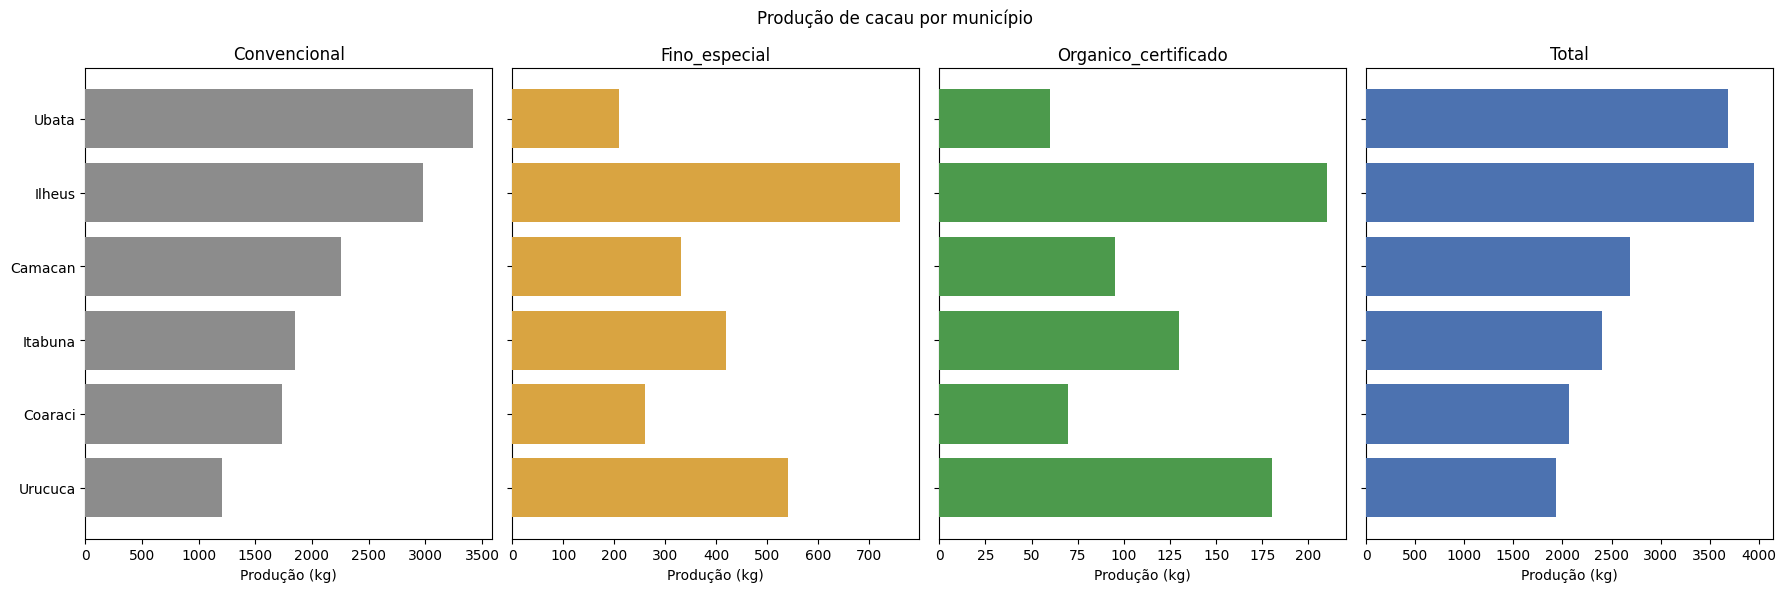

In [31]:
# Carregar os dados de produção de cacau por município
producao = pd.read_csv('../Data/producao_cacau_sintetico.csv')

tipos = ['Convencional', 'Fino_especial', 'Organico_certificado']
cores = ['#8c8c8c', '#d9a441', '#4c9a4c']
producao['Total'] = producao[tipos].sum(axis=1)
posicoes = np.arange(len(producao))

# Criar os múltiplos pequenos: um gráfico de barras (horizontais) por tipo, mais um com o total
fig, eixos = plt.subplots(1, len(tipos) + 1, figsize=(18, 6), sharey=True)

for ax, tipo, cor in zip(eixos, tipos, cores):
    ax.barh(posicoes, producao[tipo], color=cor, zorder=3)
    ax.set_title(tipo)
    ax.set_xlabel('Produção (kg)')

eixos[-1].barh(posicoes, producao['Total'], color='#4C72B0', zorder=3)
eixos[-1].set_title('Total')
eixos[-1].set_xlabel('Produção (kg)')

eixos[0].set_yticks(posicoes)
eixos[0].set_yticklabels(producao['municipio'])
eixos[0].invert_yaxis()

fig.suptitle('Produção de cacau por município')
fig.tight_layout()
plt.show()

Em ambas as versões, o espaçamento horizontal de cada segmento deve ter a mesma largura; caso contrário, pode parecer que um segmento ocupa uma proporção maior do espaço do que realmente ocupa. Nos casos em que você inclui o total, a largura não precisa ser igual à dos outros grupos, mas os intervalos ao longo do eixo devem ser os mesmos. Em outras palavras, se a largura de cada segmento — onde os dados variam de 0% a 50% — for de uma polegada, a categoria total, que abrange de 0% a 100%, deverá ter duas polegadas de largura.

Embora as diferentes linhas de base em um gráfico de barras empilhadas padrão possam dificultar a comparação de valores, há casos em que esse tipo de gráfico é preferível. Neste gráfico de barras empilhadas, incluí mais categorias de gastos e as dividi em proporções do total, de modo que o gráfico destaque a distribuição. Nessa visualização, fica claro que cerca de três quartos do gasto público total nesses países são destinados a programas de saúde e de assistência aos idosos. Essa observação é mais difícil de fazer na versão à direita, na qual cada categoria é posicionada em sua própria linha de base vertical. Embora seja mais fácil comparar as diferenças de cada categoria entre os países, não se observam grandes diferenças entre elas.

Como sempre, identifique o que você deseja mostrar e onde gostaria de concentrar a atenção do leitor. Nestes exemplos, a categoria Saúde é enfatizada porque os dados estão classificados de acordo com esses valores (apresentados como porcentagem do gasto total nesses programas específicos) e ela está posicionada ao longo da linha de base vertical. Nesse layout, os demais segmentos tornam-se secundários em relação aos gastos com saúde.

Existe um outro tipo de gráfico de barras empilhadas com o qual você talvez já tenha se deparado: aquele que mostra um único conjunto de valores de dados e a diferença entre eles e um outro valor (geralmente o total). O gráfico na página seguinte utiliza essa abordagem para exibir a proporção de mulheres eleitas para a Câmara dos Representantes dos EUA entre 1917 e 2018. A versão à esquerda apresenta as porcentagens brutas; o eixo vertical varia de 0 a 25 por cento. Nela, observa-se um aumento expressivo na participação feminina no Congresso. A versão à direita exibe os mesmos dados, mas acrescenta uma série cinza sobre os valores, completando o gráfico até a marca de 50 por cento. Essa versão permite enfatizar que a participação feminina ainda é reduzida, apesar de estar em crescimento. É justamente nessas situações — em que a proporção relativa é tão importante quanto a variação — que essa técnica pode ser particularmente valiosa.

### Variação percentual versus variação em pontos percentuais

Existe uma distinção importante entre variação percentual e variação em pontos percentuais, e esse é um erro que muitos costumam cometer.

A variação percentual compara um valor inicial (ANTIGO) a um valor final (NOVO) de acordo com esta fórmula simples: (Novo - Antigo) / Antigo × 100.

Variações percentuais positivas (ou seja, NOVO > ANTIGO) indicam um aumento percentual. Variações negativas (NOVO < ANTIGO) indicam uma queda. Você pode calcular diferenças ao longo do tempo ou entre grupos; o que realmente importa é seguir a fórmula e saber que está comparando a variação em relação ao valor inicial (ANTIGO).

A variação em pontos percentuais refere-se especificamente à análise de diferenças brutas entre porcentagens. A fórmula para essa variação é mais simples: Novo - Antigo, onde ambos já são porcentagens.

São coisas muito diferentes. Vamos tomar um exemplo simples. Segundo o Departamento do Censo dos EUA, havia 40,6 milhões de pessoas em situação de pobreza em 2016 e 39,6 milhões em 2017. A taxa de pobreza (o número de pessoas em situação de pobreza como porcentagem da população total) foi de 12,7% em 2016 e 12,3% em 2017.c

O número de pessoas em situação de pobreza caiu 2,3%. A variação percentual foi de

39,698,000 - 40,616,000)/40,616,000]×100 = [-0.023]×100 = -2.3%

Mas a taxa de pobreza caiu 0,4 ponto percentual ao longo dos dois anos:

12,3% - 12,7% = -0,4 ponto percentual

Obviamente, esses são dois números muito diferentes, mas as pessoas os confundem o tempo todo. Representar seus dados de forma clara começa por compreendê-los claramente — incluindo como foram coletados e como calcular estatísticas descritivas básicas.

## BARRA DIVERGENTE

Uma variação do gráfico de barras empilhadas é aquela em que as pilhas divergem de uma linha de base central em direções opostas. Esse tipo de gráfico é frequentemente encontrado em pesquisas nas quais as respostas estão organizadas em faixas que variam, por exemplo, de "discordo totalmente" a "concordo totalmente". Tais gráficos são frequentemente chamados de "escalas Likert", nome dado em homenagem ao psicólogo Rensis Likert, que as criou no início da década de 1930.

Neste exemplo, com base em dados do *International Social Survey Programme*, perguntou-se aos participantes da pesquisa se eles acreditam que é responsabilidade do governo reduzir a desigualdade de renda. Ao agrupar as respostas de "discordância" e "concordância" em lados opostos de uma linha de referência central, podemos comparar o sentimento geral entre os diferentes países.

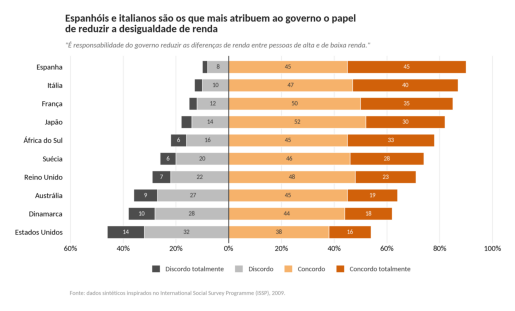

In [32]:
img = mpimg.imread('figures/fig5_likert_issp.png')
plt.imshow(img)
plt.axis('off')
plt.show()

Uma vantagem deste gráfico é que os sentimentos são apresentados de forma clara: as respostas de discordância projetam-se para a esquerda (numa direção que normalmente associamos a algo negativo) e as de concordância, para a direita. Essa abordagem funciona bem se o seu público estiver mais interessado no sentimento geral de cada lado, e não necessariamente em comparações entre os componentes individuais. Se o foco principal forem as comparações individuais, um gráfico de barras pareadas pode atender igualmente bem à necessidade.

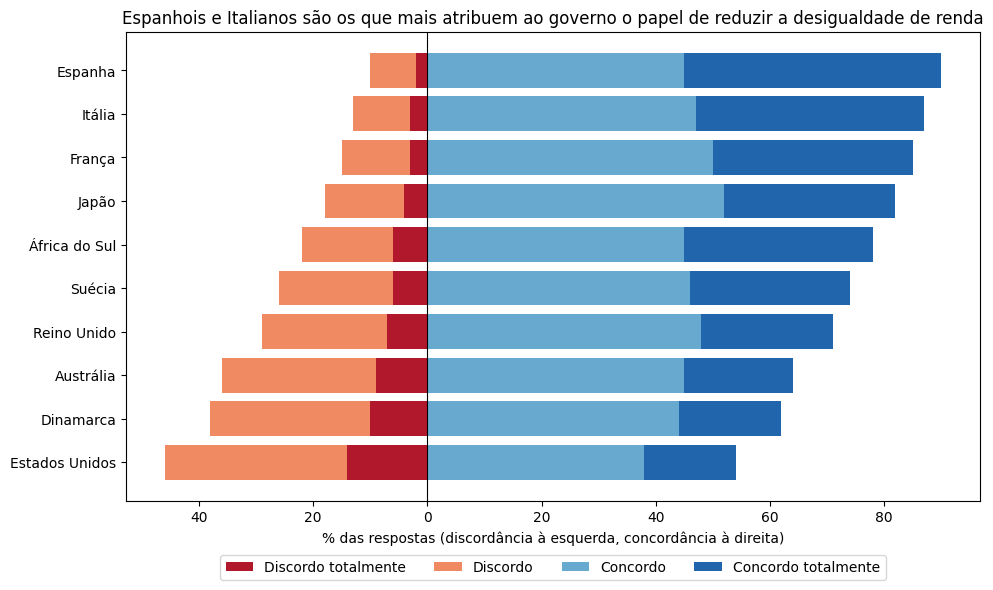

In [34]:
# Carregar os dados da pesquisa (linhas de comentário no início do arquivo)
likert = pd.read_csv('../Data/likert_issp.csv', comment='#')

# Ordenar os países pela força da concordância (Concordo + Concordo totalmente)
likert['Concordancia_total'] = likert['Concordo'] + likert['Concordo totalmente']
likert = likert.sort_values(by='Concordancia_total', ascending=True).reset_index(drop=True)

posicoes = np.arange(len(likert))

# Lado esquerdo (discordância): valores negativos, à esquerda da linha de base em zero
discordo_totalmente = -likert['Discordo totalmente']
discordo = -likert['Discordo']

# Lado direito (concordância): valores positivos, à direita da linha de base em zero
concordo = likert['Concordo']
concordo_totalmente = likert['Concordo totalmente']

fig, ax = plt.subplots(figsize=(10, 6))

# Empilhar cada lado a partir do zero, afastando-se do centro
ax.barh(posicoes, discordo_totalmente, color='#b2182b', zorder=3, label='Discordo totalmente')
ax.barh(posicoes, discordo, left=discordo_totalmente, color='#ef8a62', zorder=3, label='Discordo')
ax.barh(posicoes, concordo, color='#67a9cf', zorder=3, label='Concordo')
ax.barh(posicoes, concordo_totalmente, left=concordo, color='#2166ac', zorder=3, label='Concordo totalmente')

# Linha de base central
ax.axvline(x=0, color='black', linewidth=0.8, zorder=4)

ax.set_yticks(posicoes)
ax.set_yticklabels(likert['pais'])

ax.set_title('Espanhois e Italianos são os que mais atribuem ao governo o papel '
             'de reduzir a desigualdade de renda')
ax.set_xlabel('% das respostas (discordância à esquerda, concordância à direita)')

# Formatar o eixo x para mostrar valores absolutos (sem o sinal negativo)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(abs(x))}'))

ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=4)

fig.tight_layout()
plt.show()